# Task 3: Occasion and Gender Classification


## Experimental scope and candidate reuse

This isolated copy compares the existing CNN filter alternatives and adds MLP architectures. Production files remain unchanged.

| Family | Existing architecture reference | New alternatives |
|---|---|---|
| Shallow MLP | Dense(256), lower learning rate | Dense(64); Dense(128) |
| Deeper MLP | Dense(256, 128, 64), lower learning rate | Dense(128, 64, 32); Dense(256, 128) |
| CNN | Filters 32, 64, 128, 256 | Existing narrow, capped and wider filter experiments |

New MLP candidates retain the 96 ? 128 RGB input, dropout 0.2, training-only horizontal flips, unweighted loss, seed 2753 and batch 64. Shallow models use Adam 1e-4 and deeper models use Adam 3e-4, with a 20-epoch maximum and early-stopping patience 4. Compare architectural changes against the corresponding lower-learning-rate reference, not a differently trained original candidate. The compact deeper network changes width; the two-layer network changes depth.

Before every fit, check `models-test/<target>_<method>.keras`. Existing candidates are reloaded with their saved histories; missing candidates alone are trained. Hash, architecture, label order and normalization checks prevent accidental reuse of mismatched files. An existing model with missing or inconsistent companion files stops with an error rather than silently retraining. No optimizer resume is needed because existing files contain completed restored-best weights.

There are now 16 candidates per target: four shallow MLPs, four deeper MLPs and eight CNNs. With all previous candidates present, only four new MLP fits per target are needed (16 total across four targets). Missing previous candidates will also train. No existing CNN file is retrained. Comparisons, optional calibration/policy evaluation and selected exports are regenerated in the test folders. These experimental procedures do not imply that the production models have active calibration or review policies. Internal-test metrics must not guide selection. Nothing is automatically promoted to production.


## 1. Introduction

This notebook addresses **Task 3: Occasion and Gender Classification** for Assignment 2 by predicting the catalogue gender category and intended occasion of a fashion product from its RGB image. The task is formulated as **two separate multi-class classification problems: one model predicts gender and another predicts occasion (the metadata field `usage`)**.

Three neural-network approaches are developed and trained from scratch using TensorFlow/Keras:

- **Shallow MLP (Baseline):** A fully connected network with one 256-unit hidden layer operating on flattened image pixels.
- **Deeper MLP:** A fully connected network with hidden layers of 256, 128, and 64 units, using dropout to reduce overfitting.
- **Convolutional Neural Network (CNN):** A spatial model that learns local image patterns through convolutional layers. The complete experiment includes eight CNN candidates covering architecture, scheduling and continuation choices.

Performance is assessed using:

- **Accuracy:** The proportion of correctly classified images.
- **Macro-F1:** The primary selection metric, giving equal weight to the F1 scores of classes present in the evaluation partition.
- **Per-class classification reports and confusion matrices:** Evidence of which labels are recognized reliably and which are confused.
- **Learning curves:** Training and validation loss, accuracy, and macro-F1 used to examine convergence and overfitting.
- **Calibration metrics:** Confidence reliability of the selected model, assessed after selection using separate validation groups.

Gender labels describe the catalogue category rather than the identity of a person in an image. Occasion labels may overlap visually, and frequent categories can dominate accuracy. Each target is trained, compared, and evaluated separately.

The workflow covers metadata inspection, preprocessing, model development, comparative evaluation, selection, and export for prediction. All candidates use the same frozen group-isolated data partitions. The internal test has prior development exposure, which remains a limitation after retraining. Saved outputs record this experimental run. Its rankings and exported models are separate from the final main-notebook runs and are not automatically promoted to production.


## 2. Library Imports & Setup

Use the Fashion Keras kernel. The seed controls initialization and augmentation. Float32 is used throughout; GPU availability is reported before models are created.


In [1]:
from pathlib import Path
import sys, json, os, hashlib
from concurrent.futures import ThreadPoolExecutor
ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'scripts' / 'preprocessing.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the fashion-intelligence-classification repository.')
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, log_loss, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from scipy.optimize import minimize_scalar
import tensorflow as tf
from tensorflow import keras
from scripts.preprocessing import task_frame, IMAGE_SIZE, NORMALISATION_PATH, SEED, select_tensorflow_device
DEVICE = select_tensorflow_device()
if not tf.config.list_physical_devices('GPU') and os.environ.get('FASHION_TEST_ALLOW_CPU') != '1':
    raise RuntimeError('No TensorFlow GPU found. Use the WSL Fashion Keras environment; allow CPU explicitly with FASHION_TEST_ALLOW_CPU=1.')
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
OUTPUT, RESULTS = (ROOT / 'models-test', ROOT / 'results-test')
for directory in (OUTPUT, RESULTS):
    directory.mkdir(parents=True, exist_ok=True)
MAX_EPOCHS, BATCH_SIZE = (30, 64)

def stem_for(target):
    return 'article_type' if target == 'articleType' else target
get_ipython().run_line_magic('matplotlib', 'inline')

# False for a fresh Run All. Enable only when deliberately resuming matching saved experiments.
RESUME_SAVED_RESULTS = False


2026-09-11 21:22:32.737493: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-11 21:22:32.775190: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.20.0: /GPU:0


2026-09-11 21:22:33.669539: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 3. Load Metadata

Load valid labelled images and their frozen split assignments. Inspect paths, target labels and missing values before preprocessing.


In [2]:
metadata_by_target = {'gender': task_frame('gender'), 'usage': task_frame('usage')}
frame = metadata_by_target['gender']
print('gender', frame.shape)
display(frame.head())
frame = metadata_by_target['usage']
print('usage', frame.shape)
display(frame.head())


gender (38611, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


usage (38610, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


## 4. Data Preprocessing

Prepare the same images and label encoding for every candidate. Preserve group isolation and fit normalization on training data only.


### 4.1. Class Distribution & Balancing Strategy

Preserve the original sample distribution. Initial candidates use unweighted cross-entropy; additional CNN experiments compare this with capped square-root inverse-frequency weights computed only from training counts. No examples are duplicated, and validation metrics remain unweighted.


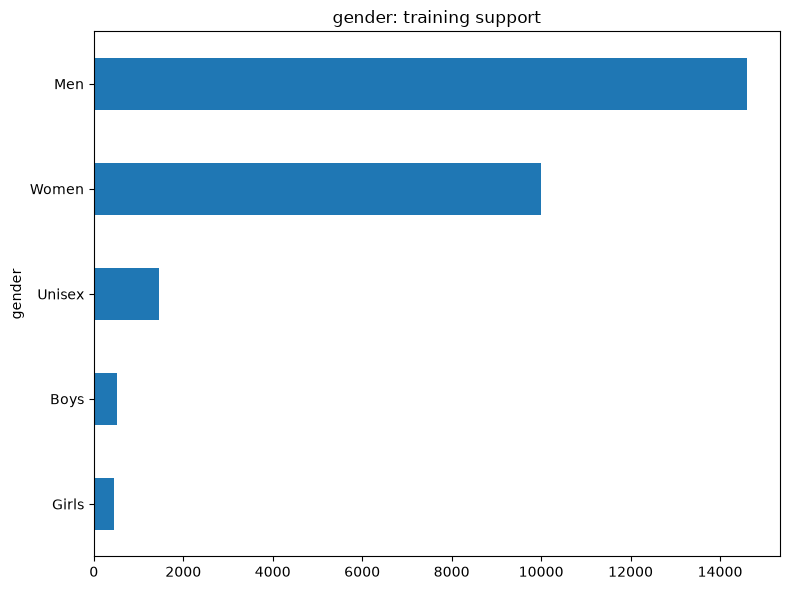

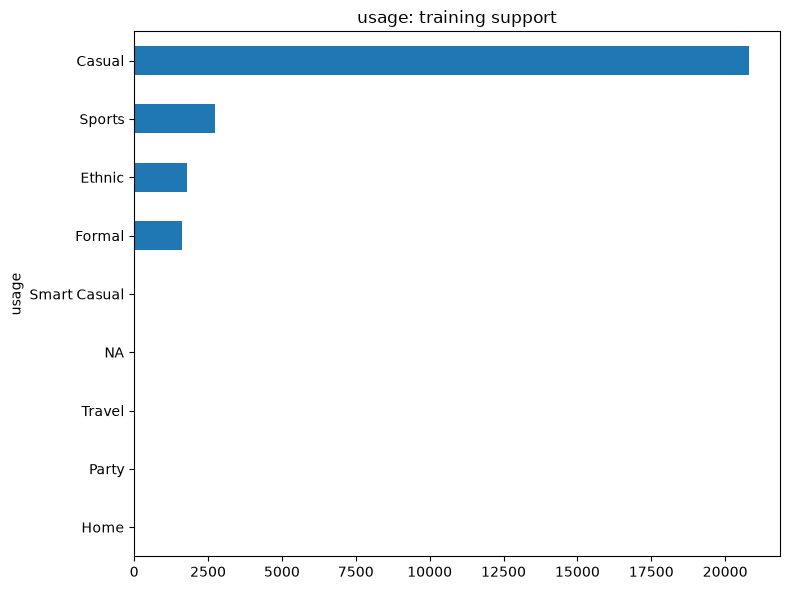

In [3]:
train_rows = metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('train')]
counts = train_rows['gender'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'gender'}: training support")
plt.tight_layout()
plt.show()
train_rows = metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('train')]
counts = train_rows['usage'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'usage'}: training support")
plt.tight_layout()
plt.show()


### 4.2. Training, Validation & Test Partitions

Reuse the frozen product-group split. Within validation, use separate groups for selection, temperature fitting and policy checking. Do not use the internal test to select candidates.


In [4]:
def validation_views(frame):
    selection_ids, rest_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
                                   .split(frame, groups=frame.group_key))
    selection, rest = frame.iloc[selection_ids], frame.iloc[rest_ids]
    cal_ids, policy_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED + 1)
                              .split(rest, groups=rest.group_key))
    return selection, rest.iloc[cal_ids], rest.iloc[policy_ids]


In [5]:
frames, labels_by_target = ({}, {})
selection, calibration, policy = validation_views(metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('validation')])
frames['gender'] = dict(train=metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('train')], selection=selection, calibration=calibration, policy=policy)
groups = [set(frame.group_key) for frame in frames['gender'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1:]))
labels_by_target['gender'] = sorted(frames['gender']['train']['gender'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['gender'].items()}, name='gender'))
selection, calibration, policy = validation_views(metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('validation')])
frames['usage'] = dict(train=metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('train')], selection=selection, calibration=calibration, policy=policy)
groups = [set(frame.group_key) for frame in frames['usage'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1:]))
labels_by_target['usage'] = sorted(frames['usage']['train']['usage'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['usage'].items()}, name='usage'))


train          27051
selection       2900
calibration     1378
policy          1564
Name: gender, dtype: int64

train          27050
selection       2900
calibration     1378
policy          1564
Name: usage, dtype: int64

### 4.3. Image Preprocessing

Resize RGB to 96 x 128 pixels (width x height), then normalize using training-only channel statistics. The batch class stores decoded uint8 images and converts one batch at a time to float32. Horizontal flips are applied inside each model only during training.


In [6]:
class CachedBatches(keras.utils.PyDataset):
    """Decode RGB once to uint8 RAM, then normalize each NHWC batch."""
    def __init__(self, frame, target, labels, normalisation, training=False, batch_size=64):
        super().__init__(workers=0, max_queue_size=2)
        self.dataset = frame
        self.training, self.batch_size = training, batch_size
        def read(path):
            with Image.open(path) as image:
                return np.asarray(image.convert("RGB").resize(IMAGE_SIZE, Image.Resampling.BILINEAR)).copy()
        with ThreadPoolExecutor(max_workers=4) as pool:
            self.images = np.stack(list(pool.map(read, frame.image_path)))
        self.targets = np.asarray([labels.index(label) for label in frame[target]], dtype=np.int32)
        self.mean = np.asarray(normalisation["mean"], dtype=np.float32)
        self.std = np.asarray(normalisation["std"], dtype=np.float32)
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(SEED)
        self.indices = np.arange(len(self.dataset))
        if self.training:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def __getitem__(self, index):
        ids = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        images = self.images[ids].astype(np.float32) / 255.0
        return (images - self.mean) / self.std, self.targets[ids]

    def on_epoch_end(self):
        if self.training:
            self.rng.shuffle(self.indices)


### 4.4. Feature Batches & Label Encoding

Map sorted label names to integer indices, preserving the same order for every model. Construct shuffled training batches and fixed-order selection batches.


In [7]:
normalisation = json.loads(NORMALISATION_PATH.read_text())
loaders = {}
labels = labels_by_target['gender']
loaders['gender'] = {name: CachedBatches(frames['gender'][name], 'gender', labels, normalisation, training=name == 'train', batch_size=BATCH_SIZE) for name in ['train', 'selection']}
labels = labels_by_target['usage']
loaders['usage'] = {name: CachedBatches(frames['usage'][name], 'usage', labels, normalisation, training=name == 'train', batch_size=BATCH_SIZE) for name in ['train', 'selection']}


## 5. Model Development & Evaluation

This section develops three neural-network families trained from scratch on the supplied fashion images. Moving from flattened pixels to deeper dense layers and then spatial convolutions lets us examine how architecture affects performance under the same evaluation protocol.

**Models included:**

- **5.1. Shallow MLP (Baseline):** Establishes the performance of one hidden layer on flattened RGB input.
- **5.2. Deeper MLP:** Tests whether additional dense layers improve the learned representation and generalization.
- **5.3. Convolutional Neural Network (CNN):** Learns spatial features and compares the declared convolutional configurations and learning-rate schedules.

Each model subsection shows its architecture, compilation, and training code. Candidates share image size, normalization, batch size and training/selection groups. Adam learning rates, early-stopping patience and epoch budgets follow each declared configuration. Training-only horizontal flips and dropout provide regularization. Early stopping restores the epoch with the highest selection macro-F1; scheduled CNNs additionally reduce the learning rate when that metric stalls.

The following subsections compare the restored models, plot learning curves, and evaluate the selected model. Model selection prioritizes **validation macro-F1**, then accuracy, then parameter count. Calibration and review thresholds use separate validation groups. The internal test is evaluated after selection and must not be used to choose an architecture.


### Evaluation Metric: Macro-F1

Accumulate the full-epoch confusion matrix and average F1 over classes with positive ground-truth support. This metric selects the restored epoch and winning model. It does not average per-batch F1 scores.

The displayed per-class classification report also includes every output label for coverage auditing. Its standard `macro avg` row therefore includes zero-support output labels and can differ from the supported-class macro-F1 used for selection. Read the explicitly reported selection metric for model ranking, and inspect support before making claims about all classes. Selection support is 97/124 article types, 4/4 seasons, 5/5 gender categories and 8/9 occasion labels for this frozen run.


In [8]:
@keras.utils.register_keras_serializable(package="Fashion")
class SupportedMacroF1(keras.metrics.Metric):
    """Macro-F1 over classes present in the full epoch's ground truth."""
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.matrix = self.add_weight(name="matrix", shape=(num_classes, num_classes), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        truth = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        predictions = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        weights = None if sample_weight is None else tf.cast(tf.reshape(sample_weight, [-1]), self.dtype)
        self.matrix.assign_add(tf.math.confusion_matrix(truth, predictions, self.num_classes,
                                                        weights=weights, dtype=self.dtype))

    def result(self):
        support = tf.reduce_sum(self.matrix, axis=1)
        predicted = tf.reduce_sum(self.matrix, axis=0)
        f1 = tf.math.divide_no_nan(2 * tf.linalg.diag_part(self.matrix), support + predicted)
        mask = tf.cast(support > 0, self.dtype)
        return tf.math.divide_no_nan(tf.reduce_sum(f1 * mask), tf.reduce_sum(mask))

    def reset_state(self):
        self.matrix.assign(tf.zeros_like(self.matrix))

    def get_config(self):
        return {**super().get_config(), "num_classes": self.num_classes}


### Saved-Model Metadata

An identity layer stores label order, preprocessing and confidence policy inside each exported Keras model.


In [9]:
@keras.utils.register_keras_serializable(package="Fashion")
class ModelMetadata(keras.layers.Layer):
    """Store label order, preprocessing and calibration inside the .keras file."""
    def __init__(self, metadata=None, **kwargs):
        super().__init__(**kwargs)
        self.metadata = dict(metadata or {})

    def call(self, inputs):
        return inputs

    def get_config(self):
        return {**super().get_config(), "metadata": dict(self.metadata)}


### Export Every Experimental Candidate

Save restored weights immediately after each fit so a later interruption does not discard completed candidates. Exports contain inference weights without optimizer storage; resuming training requires rerunning that candidate.


In [10]:
def export_candidate(target, method):
    """Save every restored candidate immediately, without optimizer slots."""
    model = models[target][method]
    metadata = dict(
        target=target, labels=labels_by_target[target], model_type=method,
        temperature=1.0, mean=normalisation['mean'], std=normalisation['std'],
        image_size=list(IMAGE_SIZE), experiment_scope='filter_comparison',
        calibration_status='uncalibrated_candidate', seed=SEED,
    )
    exported = type(model).from_config(model.get_config())
    exported.set_weights(model.get_weights())
    exported.get_layer('metadata').metadata = metadata
    path = OUTPUT / f'{stem_for(target)}_{method}.keras'
    exported.save(path)
    history = histories[target][method]
    history.to_csv(RESULTS / f'{stem_for(target)}_{method}_history.csv', index=False)
    configuration = dict(
        target=target, method=method, model_file=path.name,
        model_sha256=hashlib.sha256(path.read_bytes()).hexdigest(),
        architecture=json.loads(exported.to_json()),
        optimizer=keras.optimizers.serialize(model.optimizer),
        seed=SEED, batch_size=BATCH_SIZE, epochs_run=len(history),
        best_epoch=int(history['val_macro_f1'].to_numpy().argmax()) + 1,
        tensorflow_version=tf.__version__, keras_version=keras.__version__,
        candidate_calibrated=False,
    )
    (RESULTS / f'{stem_for(target)}_{method}_configuration.json').write_text(
        json.dumps(configuration, indent=2, default=lambda value: value.item()) + '\n')
    print('Saved candidate:', path, flush=True)


def reuse_candidate(target, method):
    """Reuse an existing export; never silently retrain an invalid existing file."""
    path = OUTPUT / f'{stem_for(target)}_{method}.keras'
    if not path.exists():
        print('TRAIN missing candidate:', path.name, flush=True)
        return False
    history_path = RESULTS / f'{stem_for(target)}_{method}_history.csv'
    config_path = RESULTS / f'{stem_for(target)}_{method}_configuration.json'
    if not history_path.is_file() or not config_path.is_file():
        raise RuntimeError(f'Existing {path.name} needs its history/configuration restored; refusing to retrain it.')
    record = json.loads(config_path.read_text())
    if hashlib.sha256(path.read_bytes()).hexdigest() != record['model_sha256']:
        raise RuntimeError(f'Hash mismatch for {path.name}; refusing to overwrite or retrain it.')
    restored = keras.models.load_model(path, compile=False)
    metadata = restored.get_layer('metadata').metadata
    assert metadata['target'] == target and metadata['model_type'] == method
    assert metadata['labels'] == labels_by_target[target]
    assert metadata['image_size'] == list(IMAGE_SIZE)
    np.testing.assert_allclose(metadata['mean'], normalisation['mean'])
    np.testing.assert_allclose(metadata['std'], normalisation['std'])
    expected = models[target][method]
    def signature(model):
        return [(type(layer).__name__, getattr(layer, 'units', None), getattr(layer, 'filters', None), getattr(layer, 'kernel_size', None), getattr(layer, 'rate', None)) for layer in model.layers]
    if signature(restored) != signature(expected):
        raise RuntimeError(f'Architecture differs for {path.name}; use a new candidate name.')
    history = pd.read_csv(history_path)
    required = {'loss', 'accuracy', 'macro_f1', 'val_loss', 'val_accuracy', 'val_macro_f1'}
    if history.empty or not required.issubset(history.columns) or len(history) != record['epochs_run']:
        raise RuntimeError(f'Incomplete history for {path.name}; refusing to retrain an existing model.')
    models[target][method] = restored
    histories[target][method] = history.drop(columns=['epoch'], errors='ignore')
    print('REUSE saved candidate:', path.name, flush=True)
    return True


In [11]:
models = {'gender': {}, 'usage': {}}
histories = {'gender': {}, 'usage': {}}


### 5.1. Shallow MLP (Baseline)


The shallow MLP is the baseline for this experiment. It learns combinations of flattened pixel values through one hidden layer but has no convolutional mechanism for local spatial patterns. Its measured performance provides the reference for the deeper models.


#### 5.1.1. Model Architecture

Flatten the image and use one 256-unit hidden layer as the baseline. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.


In [12]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
models['gender']['shallow_mlp'] = keras.Sequential(layers, name='shallow_mlp')
models['gender']['shallow_mlp'].summary()
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
models['usage']['shallow_mlp'] = keras.Sequential(layers, name='shallow_mlp')
models['usage']['shallow_mlp'].summary()


I0000 00:00:1789136680.429087     293 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "shallow_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,438,725 (36.01 MB)

 Trainable params: 9,438,725 (36.01 MB)

...

Model: "shallow_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 9)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,439,753 (36.01 MB)

 Trainable params: 9,439,753 (36.01 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.


In [13]:
model = models['gender']['shallow_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['gender']))])
model = models['usage']['shallow_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['usage']))])


#### 5.1.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.


In [14]:
loaders['gender']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
if not reuse_candidate('gender', 'shallow_mlp'):
    fitted = models['gender']['shallow_mlp'].fit(loaders['gender']['train'], validation_data=loaders['gender']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
    histories['gender']['shallow_mlp'] = pd.DataFrame(fitted.history)
    export_candidate('gender', 'shallow_mlp')
display(histories['gender']['shallow_mlp'].tail())
loaders['usage']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
if not reuse_candidate('usage', 'shallow_mlp'):
    fitted = models['usage']['shallow_mlp'].fit(loaders['usage']['train'], validation_data=loaders['usage']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
    histories['usage']['shallow_mlp'] = pd.DataFrame(fitted.history)
    export_candidate('usage', 'shallow_mlp')
display(histories['usage']['shallow_mlp'].tail())


REUSE saved candidate: gender_shallow_mlp.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
14,0.814314,0.631307,0.500280,0.823793,0.796287,0.548333
15,0.818417,0.715743,0.528978,0.806897,0.581214,0.491199
16,0.822668,0.511831,0.540228,0.823448,0.565088,0.543808
17,0.819045,0.634500,0.523984,0.820000,0.582943,0.509715
18,0.825293,0.543922,0.537619,0.823448,0.573276,0.588745


REUSE saved candidate: usage_shallow_mlp.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
25,0.852421,0.561985,0.328591,0.850690,3.062951,0.340788
26,0.845767,0.869121,0.312739,0.862414,1.197826,0.362782
27,0.857412,0.489878,0.322147,0.855862,1.025558,0.352456
28,0.860555,0.449613,0.336607,0.864828,1.027290,0.363276
29,0.860111,0.459621,0.343994,0.865172,1.159130,0.364692


#### 5.1.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


gender shallow_mlp


selection_accuracy    0.812414
selection_macro_f1    0.603752
dtype: float64

,precision,recall,f1-score,support
Boys,0.576087,0.706667,0.634731,75.000000
Girls,0.705882,0.235294,0.352941,51.000000
Men,0.809935,0.930521,0.866051,1612.000000
Unisex,0.863636,0.236025,0.370732,161.000000
Women,0.841341,0.752248,0.794304,1001.000000
accuracy,0.812414,0.812414,0.812414,0.812414
macro avg,0.759376,0.572151,0.603752,2900.000000
weighted avg,0.815879,0.812414,0.798781,2900.000000


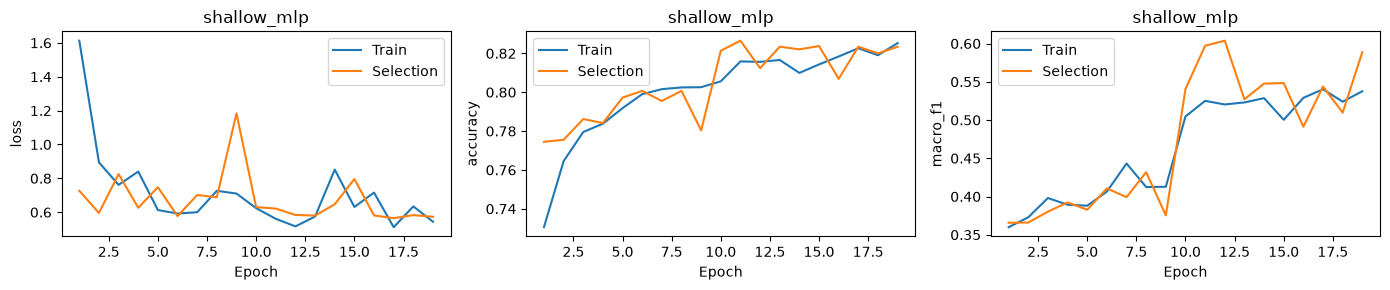

In [15]:
# Gender
loader = loaders['gender']['selection']
for method in ['shallow_mlp']:
    model = models['gender'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('gender', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['gender'])), target_names=labels_by_target['gender'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")
    history = histories['gender'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    plt.show()


usage shallow_mlp


selection_accuracy    0.865172
selection_macro_f1    0.364692
dtype: float64

,precision,recall,f1-score,support
Casual,0.874443,0.965132,0.917552,2237.000000
Ethnic,0.833333,0.632530,0.719178,166.000000
Formal,0.927928,0.578652,0.712803,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.735751,0.462541,0.568000,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.865172,0.865172,0.865172,0.865172


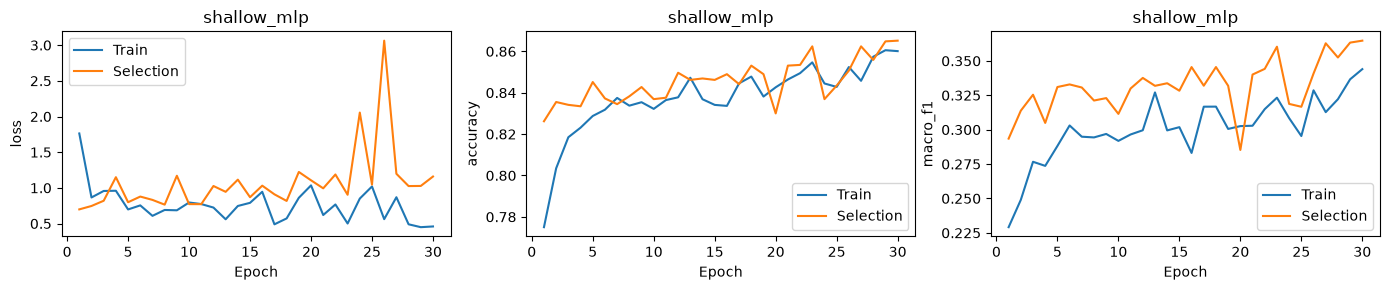

In [16]:
# Occasion (usage)
loader = loaders['usage']['selection']
for method in ['shallow_mlp']:
    model = models['usage'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('usage', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['usage'])), target_names=labels_by_target['usage'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")
    history = histories['usage'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    plt.show()


#### 5.1.5. Evaluation Analysis

The saved outputs above contain the executed selection metrics, per-class reports and learning curves for these experimental candidates. Compare supported-class macro-F1 alongside accuracy, and inspect recall/support before interpreting minority-class performance. These are experimental-run results, not the final main-notebook scores.


### 5.2. Deeper MLP


The deeper MLP processes the same flattened RGB input through three hidden layers. ReLU activations allow successive nonlinear transformations, while dropout reduces reliance on individual activations. Compare its validation metrics and learning-curve gap with the shallow baseline before concluding that depth is useful.


#### 5.2.1. Model Architecture

Flatten the image and use three hidden layers to test whether additional nonlinear transformations improve generalization. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.


In [17]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256, 128, 64]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
models['gender']['deeper_mlp'] = keras.Sequential(layers, name='deeper_mlp')
models['gender']['deeper_mlp'].summary()
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256, 128, 64]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
models['usage']['deeper_mlp'] = keras.Sequential(layers, name='deeper_mlp')
models['usage']['deeper_mlp'].summary()


Model: "deeper_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,478,917 (36.16 MB)

 Trainable params: 9,478,917 (36.16 MB)

 Non-trainable params: 0 (0.00 B)

Model: "deeper_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 9)              │           585 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 9)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,479,177 (36.16 MB)

 Trainable params: 9,479,177 (36.16 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.


In [18]:
model = models['gender']['deeper_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['gender']))])
model = models['usage']['deeper_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['usage']))])


#### 5.2.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.


In [19]:
loaders['gender']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
if not reuse_candidate('gender', 'deeper_mlp'):
    fitted = models['gender']['deeper_mlp'].fit(loaders['gender']['train'], validation_data=loaders['gender']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
    histories['gender']['deeper_mlp'] = pd.DataFrame(fitted.history)
    export_candidate('gender', 'deeper_mlp')
display(histories['gender']['deeper_mlp'].tail())
loaders['usage']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
if not reuse_candidate('usage', 'deeper_mlp'):
    fitted = models['usage']['deeper_mlp'].fit(loaders['usage']['train'], validation_data=loaders['usage']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
    histories['usage']['deeper_mlp'] = pd.DataFrame(fitted.history)
    export_candidate('usage', 'deeper_mlp')
display(histories['usage']['deeper_mlp'].tail())


REUSE saved candidate: gender_deeper_mlp.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
21,0.830357,0.466421,0.499974,0.828276,0.492412,0.520206
22,0.837899,0.455263,0.513559,0.831724,0.483622,0.522371
23,0.834535,0.462618,0.502109,0.822414,0.496615,0.511716
24,0.836494,0.450488,0.510274,0.832069,0.471522,0.528399
25,0.835755,0.453185,0.508478,0.834138,0.490199,0.518721


REUSE saved candidate: usage_deeper_mlp.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
25,0.868429,0.394817,0.327257,0.865172,0.408437,0.358216
26,0.869353,0.397032,0.326661,0.863793,0.398763,0.362389
27,0.872163,0.398829,0.330461,0.860690,0.420939,0.362216
28,0.870869,0.390677,0.329492,0.867241,0.409988,0.363699
29,0.872126,0.381992,0.330326,0.863103,0.414594,0.354327


#### 5.2.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


gender deeper_mlp


selection_accuracy    0.832069
selection_macro_f1    0.544377
dtype: float64

,precision,recall,f1-score,support
Boys,0.578947,0.733333,0.647059,75.000000
Girls,0.000000,0.000000,0.000000,51.000000
Men,0.868452,0.905087,0.886391,1612.000000
Unisex,0.947368,0.223602,0.361809,161.000000
Women,0.793928,0.862138,0.826628,1001.000000
accuracy,0.832069,0.832069,0.832069,0.832069
macro avg,0.637739,0.544832,0.544377,2900.000000
weighted avg,0.824350,0.832069,0.814861,2900.000000


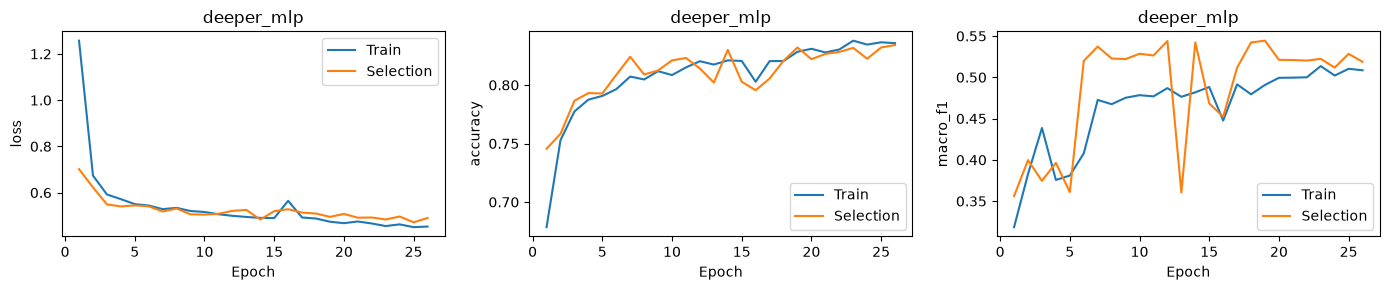

In [20]:
# Gender
loader = loaders['gender']['selection']
for method in ['deeper_mlp']:
    model = models['gender'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('gender', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['gender'])), target_names=labels_by_target['gender'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")
    history = histories['gender'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    plt.show()


usage deeper_mlp


selection_accuracy    0.865517
selection_macro_f1    0.369426
dtype: float64

,precision,recall,f1-score,support
Casual,0.880395,0.957532,0.917345,2237.000000
Ethnic,0.792683,0.783133,0.787879,166.000000
Formal,0.883333,0.595506,0.711409,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.721311,0.429967,0.538776,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.865517,0.865517,0.865517,0.865517


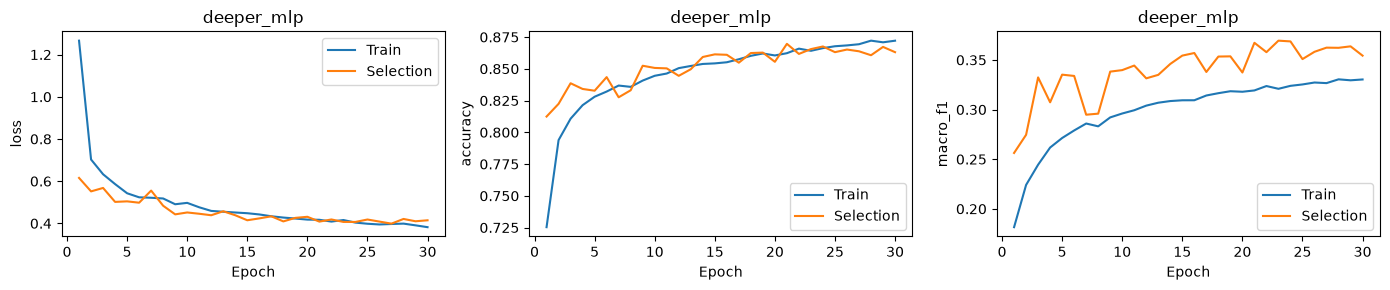

In [21]:
# Occasion (usage)
loader = loaders['usage']['selection']
for method in ['deeper_mlp']:
    model = models['usage'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('usage', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['usage'])), target_names=labels_by_target['usage'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")
    history = histories['usage'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    plt.show()


#### 5.2.5. Evaluation Analysis

The saved outputs above contain the executed selection metrics, per-class reports and learning curves for these experimental candidates. Compare supported-class macro-F1 alongside accuracy, and inspect recall/support before interpreting minority-class performance. These are experimental-run results, not the final main-notebook scores.


### 5.3. Convolutional Neural Network (CNN)

Six initial CNN configurations compare depth, scheduling and filter width. All remain members of the CNN family. The filter-only comparison uses the four scheduled four-block architectures.


#### 5.3.1. Model Architecture

Retain the two three-block controls and compare the four-block reference with narrow, capped-final-block and wider-final-block variants. All four-block candidates keep the same Dense(256) head and training recipe.


In [22]:
CNN_CONFIGS = {'cnn_ordinary': ((32, 64, 128), 128, False), 'cnn_scheduled': ((32, 64, 128), 128, True), 'cnn_four_blocks_scheduled': ((32, 64, 128, 256), 256, True), 'cnn_narrow_scheduled': ((16, 32, 64, 128), 256, True), 'cnn_capped_scheduled': ((32, 64, 128, 128), 256, True), 'cnn_wide_scheduled': ((32, 64, 128, 384), 256, True)}
for method, (channels, hidden, scheduled) in CNN_CONFIGS.items():
    keras.utils.set_random_seed(SEED)
    layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal')]
    for width in channels:
        layers.extend([keras.layers.Conv2D(width, 3, padding='same'), keras.layers.BatchNormalization(), keras.layers.Activation('relu'), keras.layers.MaxPooling2D(2)])
    h, w = (IMAGE_SIZE[1] // 2 ** len(channels), IMAGE_SIZE[0] // 2 ** len(channels))
    layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten(), keras.layers.Dense(hidden, activation='relu'), keras.layers.Dropout(0.2), keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
    models['gender'][method] = keras.Sequential(layers, name=method)
    models['gender'][method].summary()
for method, (channels, hidden, scheduled) in CNN_CONFIGS.items():
    keras.utils.set_random_seed(SEED)
    layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal')]
    for width in channels:
        layers.extend([keras.layers.Conv2D(width, 3, padding='same'), keras.layers.BatchNormalization(), keras.layers.Activation('relu'), keras.layers.MaxPooling2D(2)])
    h, w = (IMAGE_SIZE[1] // 2 ** len(channels), IMAGE_SIZE[0] // 2 ** len(channels))
    layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten(), keras.layers.Dense(hidden, activation='relu'), keras.layers.Dropout(0.2), keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
    models['usage'][method] = keras.Sequential(layers, name=method)
    models['usage'][method].summary()


Model: "cnn_ordinary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 2, 2, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,453 (626.77 KB)

 Trainable params: 160,005 (625.02 KB)

 Non-trainable params: 448 (1.75 KB)

...

Model: "cnn_wide_scheduled"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_15 (RandomFlip)     │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 12, 384)    │       442,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 16, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 16, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 8, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_11            │ (None, 2, 2, 384)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 9)              │         2,313 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 934,217 (3.56 MB)

 Trainable params: 933,001 (3.56 MB)

 Non-trainable params: 1,216 (4.75 KB)

#### 5.3.2. Compile the CNN Models

Keep optimizer, loss and metrics the same as the MLPs so the comparison tests architecture and the declared schedule.


In [23]:
for method in CNN_CONFIGS:
    models['gender'][method].compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['gender']))])
for method in CNN_CONFIGS:
    models['usage'][method].compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['usage']))])


#### 5.3.3. Train and Tune the CNN Models

Scheduled variants halve the learning rate after two epochs without improvement. All variants stop after seven stale epochs. Selection data controls these decisions; test data is not read here.


In [24]:
for method, (_, _, scheduled) in CNN_CONFIGS.items():
    loaders['gender']['train'].reset()
    callbacks = []
    if scheduled:
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2))
    callbacks.append(keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True))
    if not reuse_candidate('gender', method):
        fitted = models['gender'][method].fit(loaders['gender']['train'], validation_data=loaders['gender']['selection'], epochs=MAX_EPOCHS, callbacks=callbacks, shuffle=False, verbose=2)
        histories['gender'][method] = pd.DataFrame(fitted.history)
        export_candidate('gender', method)
    display(histories['gender'][method].tail())
for method, (_, _, scheduled) in CNN_CONFIGS.items():
    loaders['usage']['train'].reset()
    callbacks = []
    if scheduled:
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2))
    callbacks.append(keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True))
    if not reuse_candidate('usage', method):
        fitted = models['usage'][method].fit(loaders['usage']['train'], validation_data=loaders['usage']['selection'], epochs=MAX_EPOCHS, callbacks=callbacks, shuffle=False, verbose=2)
        histories['usage'][method] = pd.DataFrame(fitted.history)
        export_candidate('usage', method)
    display(histories['usage'][method].tail())


REUSE saved candidate: gender_cnn_ordinary.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
19,0.884625,0.318259,0.728220,0.737586,0.788454,0.412051
20,0.885513,0.315716,0.727441,0.814483,0.595876,0.485674
21,0.888692,0.307206,0.733734,0.788276,0.546903,0.588515
22,0.886474,0.306013,0.727533,0.858966,0.408563,0.701891
23,0.892832,0.295997,0.746735,0.766207,0.730791,0.537678


REUSE saved candidate: gender_cnn_scheduled.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1,learning_rate
19,0.892647,0.297192,0.735340,0.867241,0.380738,0.695522,0.000063
20,0.894274,0.296454,0.736413,0.867931,0.401929,0.648406,0.000063
21,0.897490,0.289808,0.749029,0.875517,0.369879,0.718127,0.000031
22,0.897231,0.289413,0.745824,0.874483,0.370868,0.728876,0.000031
23,0.898192,0.289824,0.752357,0.873103,0.371600,0.717095,0.000016


REUSE saved candidate: gender_cnn_four_blocks_scheduled.keras


...

423/423 - 27s - 63ms/step - accuracy: 0.9549 - loss: 0.1356 - macro_f1: 0.4122 - val_accuracy: 0.9024 - val_loss: 0.3130 - val_macro_f1: 0.4146 - learning_rate: 7.8125e-06


Epoch 30/30


423/423 - 27s - 63ms/step - accuracy: 0.9529 - loss: 0.1362 - macro_f1: 0.4109 - val_accuracy: 0.9041 - val_loss: 0.3136 - val_macro_f1: 0.4169 - learning_rate: 3.9063e-06


Saved candidate: /mnt/d/khoile/programs/fashion-intelligence-classification/models-test/usage_cnn_wide_scheduled.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1,learning_rate
25,0.951941,0.139657,0.409962,0.903793,0.314272,0.415713,0.000016
26,0.951904,0.139013,0.409921,0.901034,0.310417,0.415609,0.000016
27,0.954011,0.135926,0.411637,0.901724,0.312718,0.415465,0.000008
28,0.954861,0.135600,0.412225,0.902414,0.312977,0.414618,0.000008
29,0.952902,0.136193,0.410861,0.904138,0.313622,0.416928,0.000004


#### 5.3.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


gender cnn_ordinary


selection_accuracy    0.861034
selection_macro_f1    0.725045
dtype: float64

,precision,recall,f1-score,support
Boys,0.718310,0.680000,0.698630,75.000000
Girls,0.618182,0.666667,0.641509,51.000000
Men,0.876744,0.935484,0.905162,1612.000000
Unisex,0.575758,0.472050,0.518771,161.000000
Women,0.898048,0.827173,0.861154,1001.000000
accuracy,0.861034,0.861034,0.861034,0.861034
macro avg,0.737408,0.716275,0.725045,2900.000000
weighted avg,0.858743,0.861034,0.858543,2900.000000


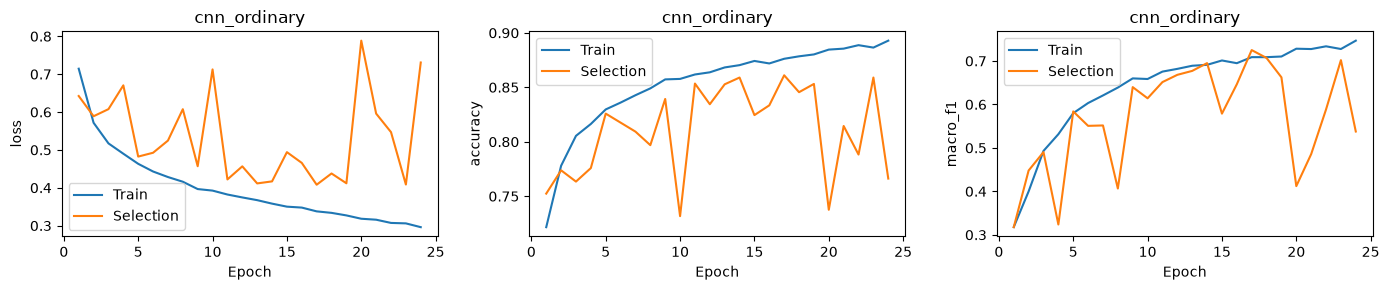

gender cnn_scheduled


selection_accuracy    0.874138
selection_macro_f1    0.735988
dtype: float64

,precision,recall,f1-score,support
Boys,0.728395,0.786667,0.756410,75.000000
Girls,0.634615,0.647059,0.640777,51.000000
Men,0.890524,0.938586,0.913923,1612.000000
Unisex,0.701149,0.378882,0.491935,161.000000
Women,0.885831,0.868132,0.876892,1001.000000
accuracy,0.874138,0.874138,0.874138,0.874138
macro avg,0.768103,0.723865,0.735988,2900.000000
weighted avg,0.869697,0.874138,0.868836,2900.000000


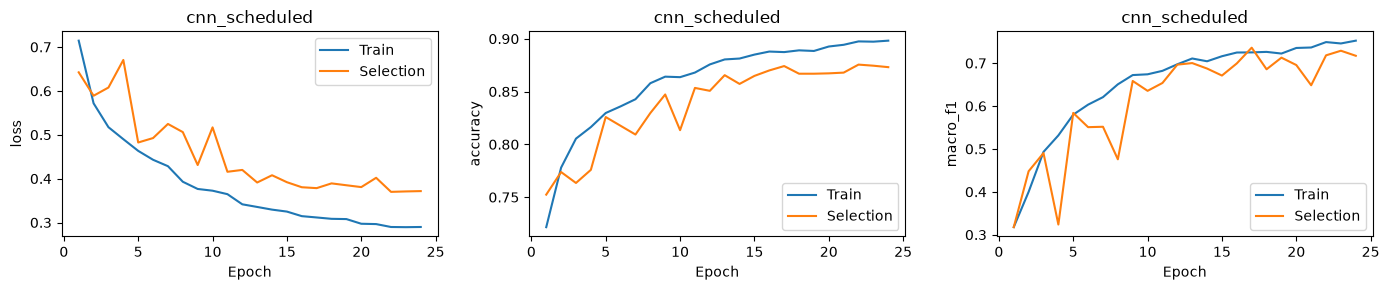

gender cnn_four_blocks_scheduled


selection_accuracy    0.898621
selection_macro_f1    0.790899
dtype: float64

,precision,recall,f1-score,support
Boys,0.735632,0.853333,0.790123,75.000000
Girls,0.765957,0.705882,0.734694,51.000000
Men,0.919686,0.944789,0.932069,1612.000000
Unisex,0.688525,0.521739,0.593640,161.000000
Women,0.909919,0.898102,0.903972,1001.000000
accuracy,0.898621,0.898621,0.898621,0.898621
macro avg,0.803944,0.784769,0.790899,2900.000000
weighted avg,0.896018,0.898621,0.896440,2900.000000


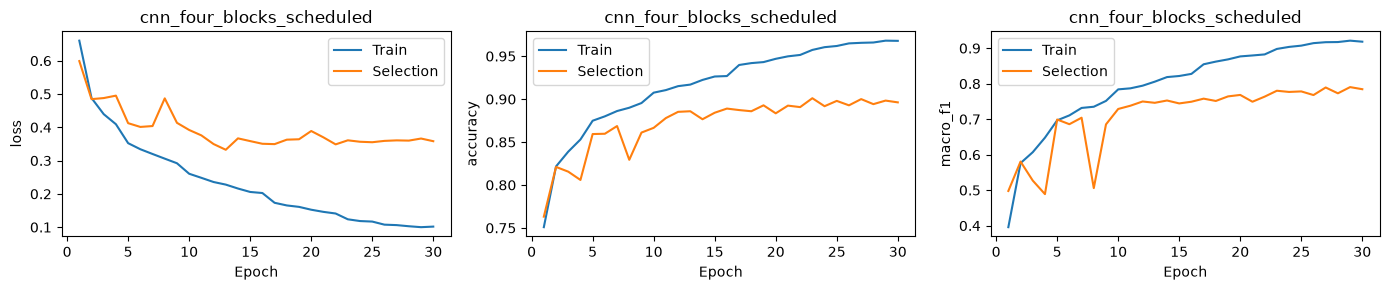

gender cnn_narrow_scheduled


selection_accuracy    0.892759
selection_macro_f1    0.772341
dtype: float64

,precision,recall,f1-score,support
Boys,0.826087,0.760000,0.791667,75.000000
Girls,0.654545,0.705882,0.679245,51.000000
Men,0.917576,0.939206,0.928265,1612.000000
Unisex,0.703704,0.472050,0.565056,161.000000
Women,0.889980,0.905095,0.897474,1001.000000
accuracy,0.892759,0.892759,0.892759,0.892759
macro avg,0.798378,0.756447,0.772341,2900.000000
weighted avg,0.889185,0.892759,0.889560,2900.000000


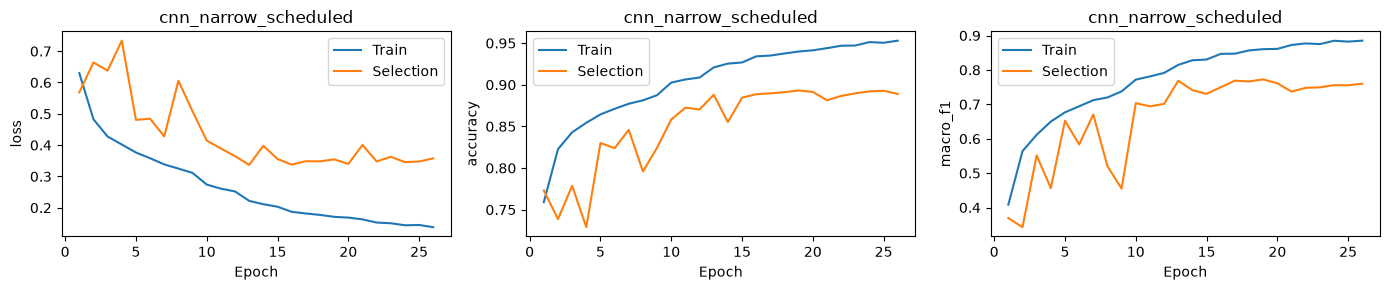

gender cnn_capped_scheduled


selection_accuracy    0.890690
selection_macro_f1    0.779792
dtype: float64

,precision,recall,f1-score,support
Boys,0.850746,0.760000,0.802817,75.00000
Girls,0.708333,0.666667,0.686869,51.00000
Men,0.918754,0.933002,0.925823,1612.00000
Unisex,0.669291,0.527950,0.590278,161.00000
Women,0.884427,0.902098,0.893175,1001.00000
accuracy,0.890690,0.890690,0.890690,0.89069
macro avg,0.806310,0.757943,0.779792,2900.00000
weighted avg,0.887596,0.890690,0.888542,2900.00000


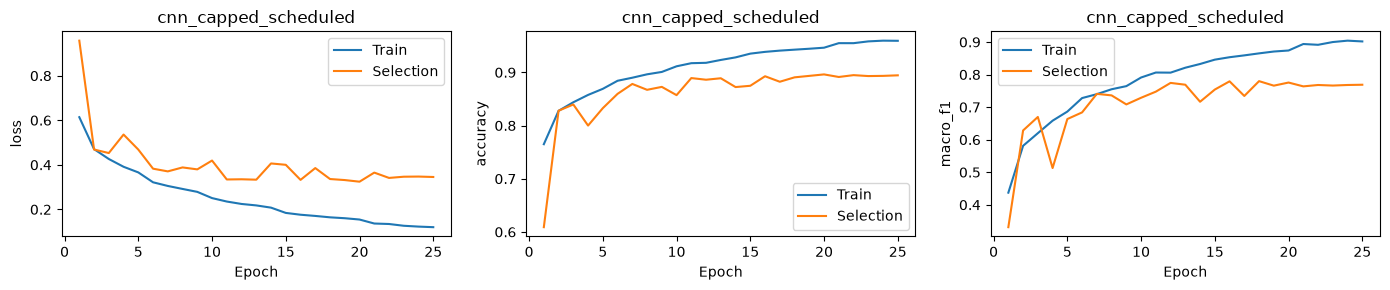

gender cnn_wide_scheduled


selection_accuracy    0.886897
selection_macro_f1    0.779147
dtype: float64

,precision,recall,f1-score,support
Boys,0.760000,0.760000,0.760000,75.000000
Girls,0.722222,0.764706,0.742857,51.000000
Men,0.908379,0.934864,0.921431,1612.000000
Unisex,0.651163,0.521739,0.579310,161.000000
Women,0.900305,0.884116,0.892137,1001.000000
accuracy,0.886897,0.886897,0.886897,0.886897
macro avg,0.788414,0.773085,0.779147,2900.000000
weighted avg,0.884201,0.886897,0.885010,2900.000000


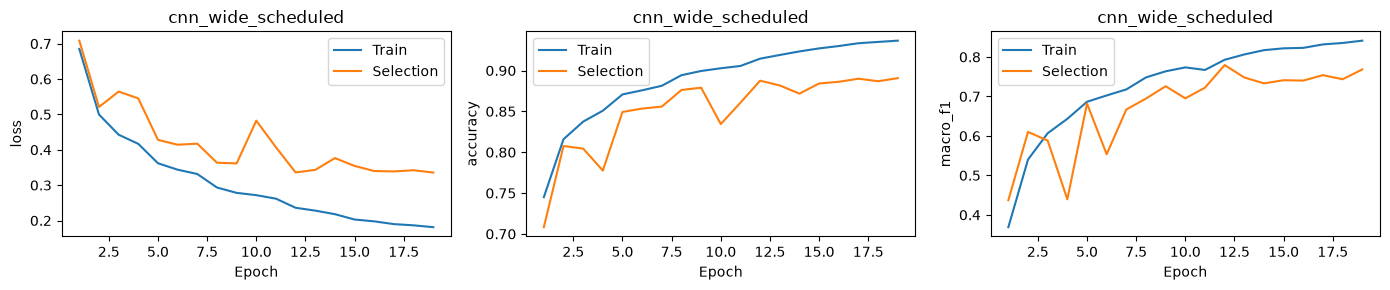

In [25]:
# Gender
loader = loaders['gender']['selection']
for method in list(CNN_CONFIGS):
    model = models['gender'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('gender', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['gender'])), target_names=labels_by_target['gender'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")
    history = histories['gender'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    plt.show()


usage cnn_ordinary


selection_accuracy    0.883103
selection_macro_f1    0.396282
dtype: float64

,precision,recall,f1-score,support
Casual,0.907106,0.947251,0.926744,2237.000000
Ethnic,0.905797,0.753012,0.822368,166.000000
Formal,0.853147,0.685393,0.760125,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.689046,0.635179,0.661017,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.883103,0.883103,0.883103,0.883103


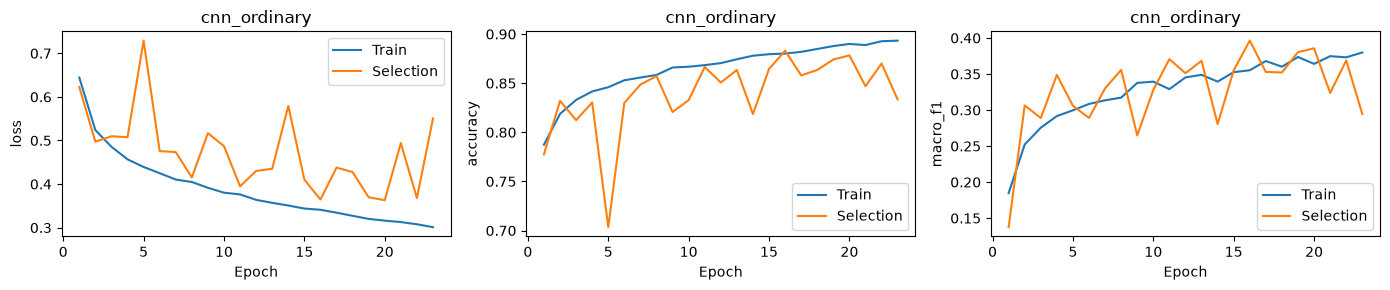

usage cnn_scheduled


selection_accuracy    0.886897
selection_macro_f1    0.396738
dtype: float64

,precision,recall,f1-score,support
Casual,0.905165,0.955744,0.929767,2237.000000
Ethnic,0.849398,0.849398,0.849398,166.000000
Formal,0.835616,0.685393,0.753086,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.756637,0.557003,0.641651,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.886897,0.886897,0.886897,0.886897


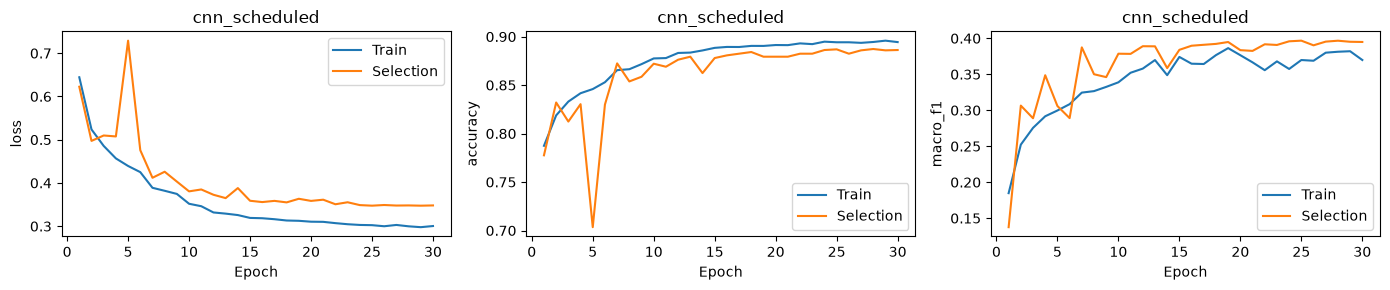

usage cnn_four_blocks_scheduled


selection_accuracy    0.904828
selection_macro_f1    0.418654
dtype: float64

,precision,recall,f1-score,support
Casual,0.928540,0.952615,0.940424,2237.000000
Ethnic,0.877193,0.903614,0.890208,166.000000
Formal,0.850932,0.769663,0.808260,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.754579,0.671010,0.710345,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.904828,0.904828,0.904828,0.904828


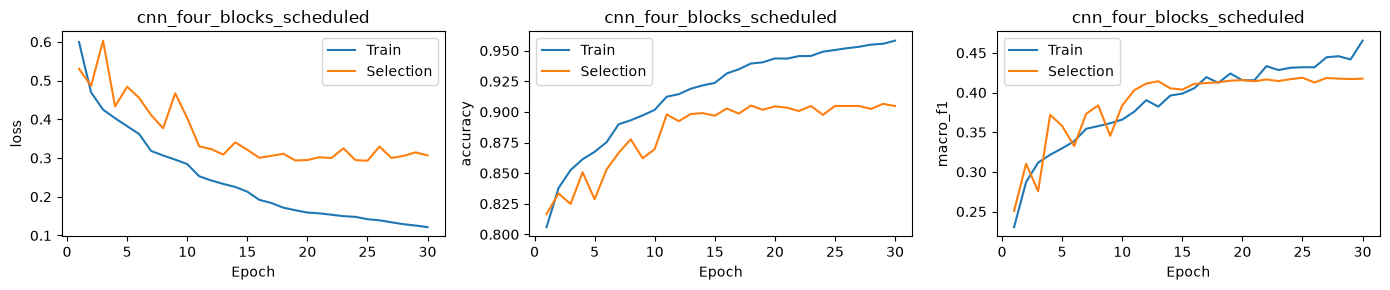

usage cnn_narrow_scheduled


selection_accuracy    0.898621
selection_macro_f1    0.412308
dtype: float64

,precision,recall,f1-score,support
Casual,0.923512,0.949933,0.936536,2237.000000
Ethnic,0.855491,0.891566,0.873156,166.000000
Formal,0.838509,0.758427,0.796460,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.747170,0.644951,0.692308,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.898621,0.898621,0.898621,0.898621


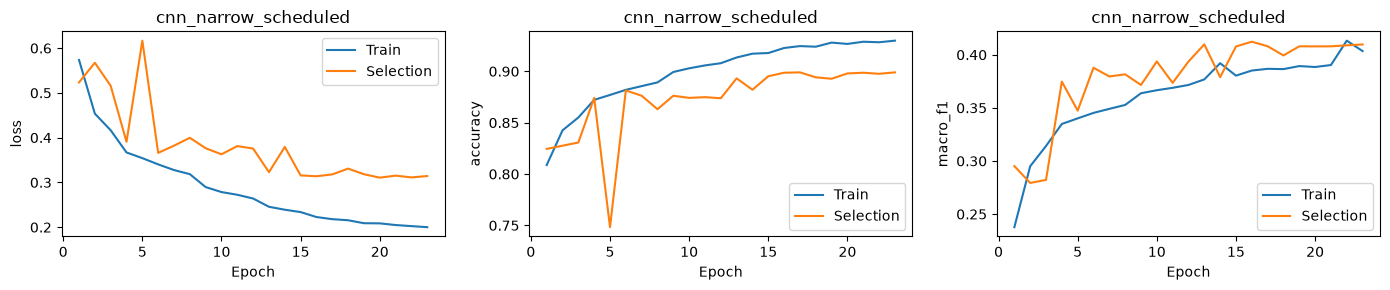

usage cnn_capped_scheduled


selection_accuracy    0.905862
selection_macro_f1    0.418692
dtype: float64

,precision,recall,f1-score,support
Casual,0.926375,0.956191,0.941047,2237.000000
Ethnic,0.890244,0.879518,0.884848,166.000000
Formal,0.855346,0.764045,0.807122,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.768657,0.671010,0.716522,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.905862,0.905862,0.905862,0.905862


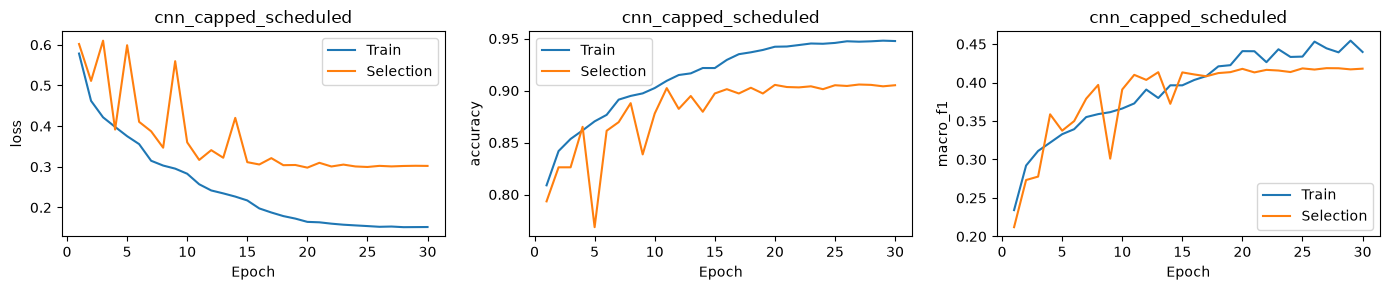

usage cnn_wide_scheduled


selection_accuracy    0.906897
selection_macro_f1    0.419797
dtype: float64

,precision,recall,f1-score,support
Casual,0.926102,0.957979,0.941771,2237.000000
Ethnic,0.892857,0.903614,0.898204,166.000000
Formal,0.865385,0.758427,0.808383,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.770992,0.657980,0.710018,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.906897,0.906897,0.906897,0.906897


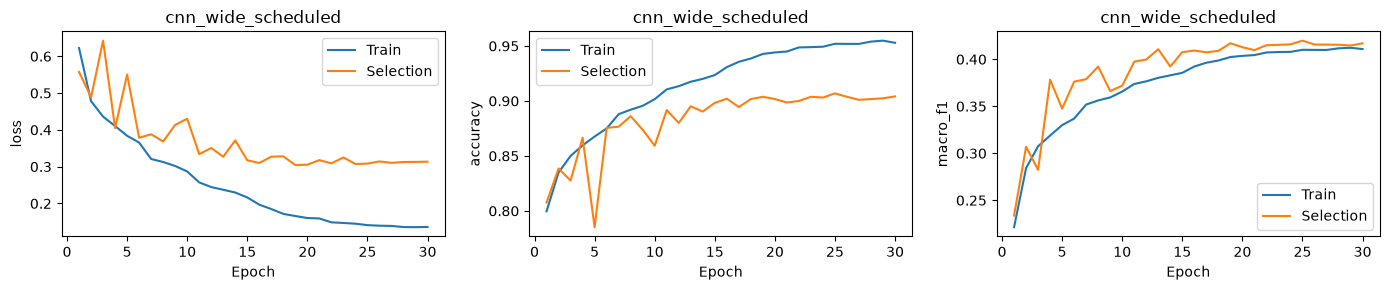

In [26]:
# Occasion (usage)
loader = loaders['usage']['selection']
for method in list(CNN_CONFIGS):
    model = models['usage'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('usage', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['usage'])), target_names=labels_by_target['usage'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")
    history = histories['usage'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    plt.show()


#### 5.3.5. Evaluation Analysis

The saved outputs above contain the executed selection metrics, per-class reports and learning curves for these experimental candidates. Compare supported-class macro-F1 alongside accuracy, and inspect recall/support before interpreting minority-class performance. These are experimental-run results, not the final main-notebook scores.


#### 5.3.6. Target-specific parameter tuning

The completed first run motivates lower learning rates for the unstable MLPs and a short CNN continuation with and without class weighting. These are additional candidates, not assumed improvements. Only training counts determine weights; selection macro-F1 chooses the winner. Calibration, policy and internal-test images are excluded from fitting.

Both CNN candidates start from identical selected CNN weights. Their shared learning rate, dropout, seed and epoch budget isolate the effect of class weights. Each MLP keeps its original architecture and uses a lower learning rate for up to 20 epochs. CNN continuation uses up to 8 additional epochs; its history records additional epochs only.

This experimental Run All reloads completed candidates and trains only missing ones. RESUME_SAVED_RESULTS remains False to prevent mixing earlier results with this run. Both continuation candidates use the fresh four-block reference, regardless of which filter alternative wins.


**gender: configure candidates and training-only weights.** Normalize square-root inverse-frequency weights to mean one over training examples, then cap them at 3 to limit the influence of extremely rare labels. Validation metrics remain unweighted.


In [27]:
PARAMETER_CONFIGS_gender = {
    'shallow_mlp_lower_lr': dict(family='shallow_mlp', learning_rate=1e-4, epochs=20, weighted=False),
    'deeper_mlp_lower_lr': dict(family='deeper_mlp', learning_rate=3e-4, epochs=20, weighted=False),
    'cnn_continue': dict(family='cnn', learning_rate=1e-05, epochs=8, weighted=False),
    'cnn_continue_weighted': dict(family='cnn', learning_rate=1e-05, epochs=8, weighted=True),
    'shallow_mlp_64': dict(family='shallow_mlp', widths=[64], learning_rate=1e-4, epochs=20, weighted=False),
    'shallow_mlp_128': dict(family='shallow_mlp', widths=[128], learning_rate=1e-4, epochs=20, weighted=False),
    'deeper_mlp_compact': dict(family='deeper_mlp', widths=[128, 64, 32], learning_rate=3e-4, epochs=20, weighted=False),
    'deeper_mlp_two_layers': dict(family='deeper_mlp', widths=[256, 128], learning_rate=3e-4, epochs=20, weighted=False),
}
counts = np.bincount(loaders['gender']['train'].targets, minlength=len(labels_by_target['gender']))
assert (counts > 0).all()
weights = np.sqrt(counts.sum() / (len(counts) * counts))
weights = np.clip(weights / np.average(weights, weights=counts), 0.25, 3)
class_weights_gender = {i: float(value) for i, value in enumerate(weights)}
if 'cnn_four_blocks_scheduled' in models['gender']:
    tuning_source_gender = models['gender']['cnn_four_blocks_scheduled']
else:
    tuning_source_gender = keras.models.load_model(OUTPUT / f"{stem_for('gender')}_model.keras", compile=False)
    saved_metadata = tuning_source_gender.get_layer('metadata').metadata
    assert saved_metadata['target'] == 'gender' and saved_metadata['labels'] == labels_by_target['gender']
    assert saved_metadata['model_type'].startswith('cnn')
    assert saved_metadata['image_size'] == list(IMAGE_SIZE)
    np.testing.assert_allclose(saved_metadata['mean'], normalisation['mean'])
    np.testing.assert_allclose(saved_metadata['std'], normalisation['std'])
    models['gender'][saved_metadata['model_type']] = tuning_source_gender
for method, config in PARAMETER_CONFIGS_gender.items():
    keras.utils.set_random_seed(SEED)
    if config['family'] == 'cnn':
        candidate = keras.models.clone_model(tuning_source_gender)
        candidate.set_weights(tuning_source_gender.get_weights())
        candidate.get_layer('metadata').metadata = {}
    else:
        widths = config.get('widths', [256] if config['family'] == 'shallow_mlp' else [256, 128, 64])
        layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
        for width in widths:
            layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
        layers.extend([keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
        candidate = keras.Sequential(layers, name=method)
    candidate.compile(optimizer=keras.optimizers.Adam(config['learning_rate']), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['gender']))])
    models['gender'][method] = candidate
pd.DataFrame(PARAMETER_CONFIGS_gender).T.to_csv(RESULTS / f"{stem_for('gender')}_parameter_configs.csv")
display(pd.DataFrame(PARAMETER_CONFIGS_gender).T)


,family,learning_rate,epochs,weighted,widths
shallow_mlp_lower_lr,shallow_mlp,0.0001,20,False,NaN
deeper_mlp_lower_lr,deeper_mlp,0.0003,20,False,NaN
cnn_continue,cnn,0.00001,8,False,NaN
cnn_continue_weighted,cnn,0.00001,8,True,NaN
shallow_mlp_64,shallow_mlp,0.0001,20,False,[64]
shallow_mlp_128,shallow_mlp,0.0001,20,False,[128]
deeper_mlp_compact,deeper_mlp,0.0003,20,False,"[128, 64, 32]"
deeper_mlp_two_layers,deeper_mlp,0.0003,20,False,"[256, 128]"


**gender: fit the additional candidates.** Early stopping restores the best selection macro-F1. Paired CNN runs reset random state and batch ordering. Class weights affect training loss only ([Keras training API](https://keras.io/api/models-test/model_training_apis/)).


In [28]:
for method, config in PARAMETER_CONFIGS_gender.items():
    keras.utils.set_random_seed(SEED)
    loaders['gender']['train'].reset()
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True)]
    print('gender', method, flush=True)
    if not reuse_candidate('gender', method):
        fitted = models['gender'][method].fit(loaders['gender']['train'], validation_data=loaders['gender']['selection'], epochs=config['epochs'], callbacks=callbacks, class_weight=class_weights_gender if config['weighted'] else None, shuffle=False, verbose=2)
        histories['gender'][method] = pd.DataFrame(fitted.history)
        export_candidate('gender', method)
    histories['gender'][method].to_csv(RESULTS / f"{stem_for('gender')}_{method}_history.csv", index=False)
    display(histories['gender'][method].tail())


gender shallow_mlp_lower_lr


TRAIN missing candidate: gender_shallow_mlp_lower_lr.keras


Epoch 1/20


423/423 - 9s - 22ms/step - accuracy: 0.7737 - loss: 0.6562 - macro_f1: 0.5008 - val_accuracy: 0.8121 - val_loss: 0.5504 - val_macro_f1: 0.5726


Epoch 2/20


...

423/423 - 9s - 22ms/step - accuracy: 0.8446 - loss: 0.4327 - macro_f1: 0.6258 - val_accuracy: 0.8403 - val_loss: 0.4649 - val_macro_f1: 0.6387


Epoch 20/20


423/423 - 9s - 22ms/step - accuracy: 0.8421 - loss: 0.4264 - macro_f1: 0.6219 - val_accuracy: 0.8428 - val_loss: 0.4518 - val_macro_f1: 0.6886


Saved candidate: /mnt/d/khoile/programs/fashion-intelligence-classification/models-test/gender_deeper_mlp_two_layers.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
15,0.838823,0.442615,0.601081,0.837931,0.472301,0.653075
16,0.840191,0.441271,0.606270,0.830345,0.495285,0.605926
17,0.840671,0.447914,0.608822,0.845172,0.466388,0.691177
18,0.844553,0.432725,0.625757,0.840345,0.464854,0.638690
19,0.842076,0.426434,0.621918,0.842759,0.451762,0.688632


**gender: evaluate on selection images.** The final comparison keeps the best candidate within each family. Rare-class recall accompanies overall scores; continuation is retained only if it wins the declared ranking.


In [29]:
loader = loaders['gender']['selection']
for method in PARAMETER_CONFIGS_gender:
    probabilities = np.vstack([tf.nn.softmax(models['gender'][method](loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(1)
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['gender'])), target_names=labels_by_target['gender'], output_dict=True, zero_division=0)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")
    display(pd.Series(dict(method=method, accuracy=accuracy_score(loader.targets, predictions), macro_f1=f1_score(loader.targets, predictions, labels=np.unique(loader.targets), average='macro', zero_division=0))))


method      shallow_mlp_lower_lr
accuracy                0.846897
macro_f1                0.711753
dtype: object

method      deeper_mlp_lower_lr
accuracy               0.818276
macro_f1                0.61767
dtype: object

method      cnn_continue
accuracy        0.896552
macro_f1        0.784471
dtype: object

method      cnn_continue_weighted
accuracy                 0.895517
macro_f1                 0.785438
dtype: object

method      shallow_mlp_64
accuracy          0.844483
macro_f1          0.694929
dtype: object

method      shallow_mlp_128
accuracy           0.851724
macro_f1           0.701315
dtype: object

method      deeper_mlp_compact
accuracy              0.834483
macro_f1              0.678565
dtype: object

method      deeper_mlp_two_layers
accuracy                 0.845172
macro_f1                 0.691177
dtype: object

**usage: configure candidates and training-only weights.** Normalize square-root inverse-frequency weights to mean one over training examples, then cap them at 6 to limit the influence of extremely rare labels. Validation metrics remain unweighted.


In [30]:
PARAMETER_CONFIGS_usage = {
    'shallow_mlp_lower_lr': dict(family='shallow_mlp', learning_rate=1e-4, epochs=20, weighted=False),
    'deeper_mlp_lower_lr': dict(family='deeper_mlp', learning_rate=3e-4, epochs=20, weighted=False),
    'cnn_continue': dict(family='cnn', learning_rate=3e-05, epochs=8, weighted=False),
    'cnn_continue_weighted': dict(family='cnn', learning_rate=3e-05, epochs=8, weighted=True),
    'shallow_mlp_64': dict(family='shallow_mlp', widths=[64], learning_rate=1e-4, epochs=20, weighted=False),
    'shallow_mlp_128': dict(family='shallow_mlp', widths=[128], learning_rate=1e-4, epochs=20, weighted=False),
    'deeper_mlp_compact': dict(family='deeper_mlp', widths=[128, 64, 32], learning_rate=3e-4, epochs=20, weighted=False),
    'deeper_mlp_two_layers': dict(family='deeper_mlp', widths=[256, 128], learning_rate=3e-4, epochs=20, weighted=False),
}
counts = np.bincount(loaders['usage']['train'].targets, minlength=len(labels_by_target['usage']))
assert (counts > 0).all()
weights = np.sqrt(counts.sum() / (len(counts) * counts))
weights = np.clip(weights / np.average(weights, weights=counts), 0.25, 6)
class_weights_usage = {i: float(value) for i, value in enumerate(weights)}
if 'cnn_four_blocks_scheduled' in models['usage']:
    tuning_source_usage = models['usage']['cnn_four_blocks_scheduled']
else:
    tuning_source_usage = keras.models.load_model(OUTPUT / f"{stem_for('usage')}_model.keras", compile=False)
    saved_metadata = tuning_source_usage.get_layer('metadata').metadata
    assert saved_metadata['target'] == 'usage' and saved_metadata['labels'] == labels_by_target['usage']
    assert saved_metadata['model_type'].startswith('cnn')
    assert saved_metadata['image_size'] == list(IMAGE_SIZE)
    np.testing.assert_allclose(saved_metadata['mean'], normalisation['mean'])
    np.testing.assert_allclose(saved_metadata['std'], normalisation['std'])
    models['usage'][saved_metadata['model_type']] = tuning_source_usage
for method, config in PARAMETER_CONFIGS_usage.items():
    keras.utils.set_random_seed(SEED)
    if config['family'] == 'cnn':
        candidate = keras.models.clone_model(tuning_source_usage)
        candidate.set_weights(tuning_source_usage.get_weights())
        candidate.get_layer('metadata').metadata = {}
    else:
        widths = config.get('widths', [256] if config['family'] == 'shallow_mlp' else [256, 128, 64])
        layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
        for width in widths:
            layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
        layers.extend([keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
        candidate = keras.Sequential(layers, name=method)
    candidate.compile(optimizer=keras.optimizers.Adam(config['learning_rate']), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['usage']))])
    models['usage'][method] = candidate
pd.DataFrame(PARAMETER_CONFIGS_usage).T.to_csv(RESULTS / f"{stem_for('usage')}_parameter_configs.csv")
display(pd.DataFrame(PARAMETER_CONFIGS_usage).T)


,family,learning_rate,epochs,weighted,widths
shallow_mlp_lower_lr,shallow_mlp,0.0001,20,False,NaN
deeper_mlp_lower_lr,deeper_mlp,0.0003,20,False,NaN
cnn_continue,cnn,0.00003,8,False,NaN
cnn_continue_weighted,cnn,0.00003,8,True,NaN
shallow_mlp_64,shallow_mlp,0.0001,20,False,[64]
shallow_mlp_128,shallow_mlp,0.0001,20,False,[128]
deeper_mlp_compact,deeper_mlp,0.0003,20,False,"[128, 64, 32]"
deeper_mlp_two_layers,deeper_mlp,0.0003,20,False,"[256, 128]"


**usage: fit the additional candidates.** Early stopping restores the best selection macro-F1. Paired CNN runs reset random state and batch ordering. Class weights affect training loss only ([Keras training API](https://keras.io/api/models-test/model_training_apis/)).


In [31]:
for method, config in PARAMETER_CONFIGS_usage.items():
    keras.utils.set_random_seed(SEED)
    loaders['usage']['train'].reset()
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True)]
    print('usage', method, flush=True)
    if not reuse_candidate('usage', method):
        fitted = models['usage'][method].fit(loaders['usage']['train'], validation_data=loaders['usage']['selection'], epochs=config['epochs'], callbacks=callbacks, class_weight=class_weights_usage if config['weighted'] else None, shuffle=False, verbose=2)
        histories['usage'][method] = pd.DataFrame(fitted.history)
        export_candidate('usage', method)
    histories['usage'][method].to_csv(RESULTS / f"{stem_for('usage')}_{method}_history.csv", index=False)
    display(histories['usage'][method].tail())


usage shallow_mlp_lower_lr


TRAIN missing candidate: usage_shallow_mlp_lower_lr.keras


Epoch 1/20


423/423 - 10s - 24ms/step - accuracy: 0.8059 - loss: 0.6590 - macro_f1: 0.2581 - val_accuracy: 0.8352 - val_loss: 0.5188 - val_macro_f1: 0.3129


Epoch 2/20


...

423/423 - 10s - 23ms/step - accuracy: 0.8651 - loss: 0.4108 - macro_f1: 0.3350 - val_accuracy: 0.8641 - val_loss: 0.4236 - val_macro_f1: 0.3659


Epoch 20/20


423/423 - 10s - 23ms/step - accuracy: 0.8652 - loss: 0.4243 - macro_f1: 0.3255 - val_accuracy: 0.8648 - val_loss: 0.4735 - val_macro_f1: 0.3564


Saved candidate: /mnt/d/khoile/programs/fashion-intelligence-classification/models-test/usage_deeper_mlp_two_layers.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
15,0.861516,0.446306,0.329509,0.857931,0.455905,0.355474
16,0.861516,0.454388,0.330032,0.858621,0.442314,0.355920
17,0.864251,0.426928,0.324327,0.868276,0.472739,0.367322
18,0.865102,0.410754,0.334990,0.864138,0.423584,0.365909
19,0.865250,0.424309,0.325504,0.864828,0.473492,0.356427


**usage: evaluate on selection images.** The final comparison keeps the best candidate within each family. Rare-class recall accompanies overall scores; continuation is retained only if it wins the declared ranking.


In [32]:
loader = loaders['usage']['selection']
for method in PARAMETER_CONFIGS_usage:
    probabilities = np.vstack([tf.nn.softmax(models['usage'][method](loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(1)
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['usage'])), target_names=labels_by_target['usage'], output_dict=True, zero_division=0)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")
    display(pd.Series(dict(method=method, accuracy=accuracy_score(loader.targets, predictions), macro_f1=f1_score(loader.targets, predictions, labels=np.unique(loader.targets), average='macro', zero_division=0))))


method      shallow_mlp_lower_lr
accuracy                0.873793
macro_f1                0.452185
dtype: object

method      deeper_mlp_lower_lr
accuracy               0.853793
macro_f1               0.362344
dtype: object

method      cnn_continue
accuracy        0.905517
macro_f1         0.41838
dtype: object

method      cnn_continue_weighted
accuracy                 0.895517
macro_f1                 0.449732
dtype: object

method      shallow_mlp_64
accuracy          0.852759
macro_f1           0.38966
dtype: object

method      shallow_mlp_128
accuracy           0.857931
macro_f1           0.362978
dtype: object

method      deeper_mlp_compact
accuracy               0.86069
macro_f1              0.357907
dtype: object

method      deeper_mlp_two_layers
accuracy                 0.868276
macro_f1                 0.367322
dtype: object

### 5.4. Model Comparison

Choose the best configuration within each of the three families using selection macro-F1, then accuracy, then fewer parameters. Original runs and the additional parameter experiments are compared on the same selection partition. The three-row table reports family winners; the experiments CSV retains candidate-level evidence.


In [33]:
def supported_macro_f1(truth, predictions) -> float:
    """Macro-average over labels present in the ground-truth partition."""
    return float(f1_score(
        truth, predictions, labels=np.unique(truth), average="macro", zero_division=0
    ))

def expected_calibration_error(
    truth: np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    """Compute top-label expected calibration error."""
    truth = np.asarray(truth)
    probabilities = np.asarray(probabilities)
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == truth
    edges = np.linspace(0.0, 1.0, bins + 1)
    total = len(truth)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:], strict=True):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            error += selected.sum() / total * abs(
                float(correct[selected].mean()) - float(confidence[selected].mean())
            )
    return float(error)

def ranked(table):
    """Predeclared: macro F1, then accuracy, then fewer parameters."""
    return table.sort_values(['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
                             ascending=[False, False, True], kind='stable')


In [34]:
# Gender
comparisons, tuning, winners, checkpoints = ({}, {}, {}, {})
rows = []
loader = loaders['gender']['selection']
for method, model in models['gender'].items():
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    rows.append(dict(method=method, validation_accuracy=accuracy_score(loader.targets, probabilities.argmax(1)), validation_macro_f1=supported_macro_f1(loader.targets, probabilities.argmax(1)), validation_ece=expected_calibration_error(loader.targets, probabilities), complexity_parameters=model.count_params(), epochs_run=len(histories['gender'][method])))
experiments = pd.DataFrame(rows).set_index('method')
# Resume measured candidates whose weights were not exported after kernel shutdown.
previous_path = RESULTS / f"{stem_for('gender')}_experiments.csv"
if RESUME_SAVED_RESULTS and previous_path.exists():
    previous = pd.read_csv(previous_path, index_col='method')
    experiments = pd.concat([previous.loc[~previous.index.isin(experiments.index)], experiments])
experiments.to_csv(RESULTS / f"{stem_for('gender')}_experiments.csv")
tuning['gender'] = experiments.loc[experiments.index.str.startswith('cnn')].copy()
for metric in ['accuracy', 'macro_f1']:
    tuning['gender'][f'{metric}_change_vs_ordinary'] = tuning['gender'][f'validation_{metric}'] - tuning['gender'].loc['cnn_ordinary', f'validation_{metric}']
best_cnn = ranked(tuning['gender']).index[0]
best_shallow = ranked(experiments.loc[experiments.index.str.startswith('shallow_mlp')]).index[0]
best_deeper = ranked(experiments.loc[experiments.index.str.startswith('deeper_mlp')]).index[0]
table = experiments.loc[[best_shallow, best_deeper, best_cnn]].copy()
table['family'] = ['shallow_mlp', 'deeper_mlp', 'cnn']
winners['gender'] = ranked(table).index[0]
table['selected'] = table.index == winners['gender']
comparisons['gender'] = table
table.to_csv(RESULTS / f"{stem_for('gender')}_comparison.csv")
tuning['gender'].to_csv(RESULTS / f"{stem_for('gender')}_cnn_tuning.csv")
display(table)
display(tuning['gender'])
assert winners['gender'] in models['gender'], 'Winning weights are missing; retrain that candidate before export.'


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,family,selected
method,,,,,,,
shallow_mlp_lower_lr,0.846897,0.711753,0.020750,9438725,12,shallow_mlp,False
deeper_mlp_two_layers,0.845172,0.691177,0.032483,9470981,20,deeper_mlp,False
cnn_four_blocks_scheduled,0.898621,0.790899,0.044431,654021,30,cnn,True


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary
method,,,,,,,
cnn_ordinary,0.861034,0.725045,0.054873,160453,24,0.000000,0.000000
cnn_scheduled,0.874138,0.735988,0.017495,160453,24,0.013103,0.010942
cnn_four_blocks_scheduled,0.898621,0.790899,0.044431,654021,30,0.037586,0.065854
cnn_narrow_scheduled,0.892759,0.772341,0.030694,231013,26,0.031724,0.047296
cnn_capped_scheduled,0.890690,0.779792,0.027206,374853,25,0.029655,0.054747
cnn_wide_scheduled,0.886897,0.779147,0.016744,933189,19,0.025862,0.054102
cnn_continue,0.896552,0.784471,0.039696,654021,5,0.035517,0.059425
cnn_continue_weighted,0.895517,0.785438,0.036268,654021,8,0.034483,0.060393


#### Filter-only comparison

Compare only equally trained four-block CNNs here. Gains are relative to the fresh reference run, not the separately continued production winner.


In [35]:
filter_methods = ['cnn_four_blocks_scheduled', 'cnn_narrow_scheduled', 'cnn_capped_scheduled', 'cnn_wide_scheduled']
filter_table = tuning['gender'].loc[filter_methods].copy()
reference = filter_table.loc['cnn_four_blocks_scheduled']
filter_table['macro_f1_change_vs_reference'] = filter_table.validation_macro_f1 - reference.validation_macro_f1
filter_table['accuracy_change_vs_reference'] = filter_table.validation_accuracy - reference.validation_accuracy
filter_table = ranked(filter_table)
filter_table.to_csv(RESULTS / f"{stem_for('gender')}_filter_comparison.csv")
display(filter_table)


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary,macro_f1_change_vs_reference,accuracy_change_vs_reference
method,,,,,,,,,
cnn_four_blocks_scheduled,0.898621,0.790899,0.044431,654021,30,0.037586,0.065854,0.000000,0.000000
cnn_capped_scheduled,0.890690,0.779792,0.027206,374853,25,0.029655,0.054747,-0.011107,-0.007931
cnn_wide_scheduled,0.886897,0.779147,0.016744,933189,19,0.025862,0.054102,-0.011752,-0.011724
cnn_narrow_scheduled,0.892759,0.772341,0.030694,231013,26,0.031724,0.047296,-0.018558,-0.005862


In [36]:
# Occasion (usage)
rows = []
loader = loaders['usage']['selection']
for method, model in models['usage'].items():
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    rows.append(dict(method=method, validation_accuracy=accuracy_score(loader.targets, probabilities.argmax(1)), validation_macro_f1=supported_macro_f1(loader.targets, probabilities.argmax(1)), validation_ece=expected_calibration_error(loader.targets, probabilities), complexity_parameters=model.count_params(), epochs_run=len(histories['usage'][method])))
experiments = pd.DataFrame(rows).set_index('method')
# Resume measured candidates whose weights were not exported after kernel shutdown.
previous_path = RESULTS / f"{stem_for('usage')}_experiments.csv"
if RESUME_SAVED_RESULTS and previous_path.exists():
    previous = pd.read_csv(previous_path, index_col='method')
    experiments = pd.concat([previous.loc[~previous.index.isin(experiments.index)], experiments])
experiments.to_csv(RESULTS / f"{stem_for('usage')}_experiments.csv")
tuning['usage'] = experiments.loc[experiments.index.str.startswith('cnn')].copy()
for metric in ['accuracy', 'macro_f1']:
    tuning['usage'][f'{metric}_change_vs_ordinary'] = tuning['usage'][f'validation_{metric}'] - tuning['usage'].loc['cnn_ordinary', f'validation_{metric}']
best_cnn = ranked(tuning['usage']).index[0]
best_shallow = ranked(experiments.loc[experiments.index.str.startswith('shallow_mlp')]).index[0]
best_deeper = ranked(experiments.loc[experiments.index.str.startswith('deeper_mlp')]).index[0]
table = experiments.loc[[best_shallow, best_deeper, best_cnn]].copy()
table['family'] = ['shallow_mlp', 'deeper_mlp', 'cnn']
winners['usage'] = ranked(table).index[0]
table['selected'] = table.index == winners['usage']
comparisons['usage'] = table
table.to_csv(RESULTS / f"{stem_for('usage')}_comparison.csv")
tuning['usage'].to_csv(RESULTS / f"{stem_for('usage')}_cnn_tuning.csv")
display(table)
display(tuning['usage'])
assert winners['usage'] in models['usage'], 'Winning weights are missing; retrain that candidate before export.'


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,family,selected
method,,,,,,,
shallow_mlp_lower_lr,0.873793,0.452185,0.023828,9439753,14,shallow_mlp,True
deeper_mlp,0.865517,0.369426,0.012320,9479177,30,deeper_mlp,False
cnn_continue_weighted,0.895517,0.449732,0.028263,655049,8,cnn,False


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary
method,,,,,,,
cnn_ordinary,0.883103,0.396282,0.015930,160969,23,0.000000,0.000000
cnn_scheduled,0.886897,0.396738,0.014970,160969,30,0.003793,0.000456
cnn_four_blocks_scheduled,0.904828,0.418654,0.028082,655049,30,0.021724,0.022373
cnn_narrow_scheduled,0.898621,0.412308,0.018657,232041,23,0.015517,0.016026
cnn_capped_scheduled,0.905862,0.418692,0.029274,375881,30,0.022759,0.022411
cnn_wide_scheduled,0.906897,0.419797,0.034649,934217,30,0.023793,0.023515
cnn_continue,0.905517,0.418380,0.038527,655049,5,0.022414,0.022099
cnn_continue_weighted,0.895517,0.449732,0.028263,655049,8,0.012414,0.053450


#### Filter-only comparison

Compare only equally trained four-block CNNs here. Gains are relative to the fresh reference run, not the separately continued production winner.


In [37]:
filter_methods = ['cnn_four_blocks_scheduled', 'cnn_narrow_scheduled', 'cnn_capped_scheduled', 'cnn_wide_scheduled']
filter_table = tuning['usage'].loc[filter_methods].copy()
reference = filter_table.loc['cnn_four_blocks_scheduled']
filter_table['macro_f1_change_vs_reference'] = filter_table.validation_macro_f1 - reference.validation_macro_f1
filter_table['accuracy_change_vs_reference'] = filter_table.validation_accuracy - reference.validation_accuracy
filter_table = ranked(filter_table)
filter_table.to_csv(RESULTS / f"{stem_for('usage')}_filter_comparison.csv")
display(filter_table)


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary,macro_f1_change_vs_reference,accuracy_change_vs_reference
method,,,,,,,,,
cnn_wide_scheduled,0.906897,0.419797,0.034649,934217,30,0.023793,0.023515,0.001142,0.002069
cnn_capped_scheduled,0.905862,0.418692,0.029274,375881,30,0.022759,0.022411,0.000038,0.001034
cnn_four_blocks_scheduled,0.904828,0.418654,0.028082,655049,30,0.021724,0.022373,0.000000,0.000000
cnn_narrow_scheduled,0.898621,0.412308,0.018657,232041,23,0.015517,0.016026,-0.006347,-0.006207


#### MLP architecture comparisons

Each family uses the lower-learning-rate reference with the same training budget. These tables isolate architectural changes from learning-rate changes.


In [38]:

all_scores = pd.read_csv(RESULTS / f"{stem_for('gender')}_experiments.csv", index_col='method')
for family, methods in {'shallow_mlp': ['shallow_mlp_lower_lr', 'shallow_mlp_64', 'shallow_mlp_128'], 'deeper_mlp': ['deeper_mlp_lower_lr', 'deeper_mlp_compact', 'deeper_mlp_two_layers']}.items():
    architecture_table = all_scores.loc[methods].copy()
    architecture_table['macro_f1_change_vs_reference'] = architecture_table.validation_macro_f1 - architecture_table.iloc[0].validation_macro_f1
    architecture_table = ranked(architecture_table)
    architecture_table.to_csv(RESULTS / f"{stem_for('gender')}_{family}_architecture_comparison.csv")
    display(architecture_table)

all_scores = pd.read_csv(RESULTS / f"{stem_for('usage')}_experiments.csv", index_col='method')
for family, methods in {'shallow_mlp': ['shallow_mlp_lower_lr', 'shallow_mlp_64', 'shallow_mlp_128'], 'deeper_mlp': ['deeper_mlp_lower_lr', 'deeper_mlp_compact', 'deeper_mlp_two_layers']}.items():
    architecture_table = all_scores.loc[methods].copy()
    architecture_table['macro_f1_change_vs_reference'] = architecture_table.validation_macro_f1 - architecture_table.iloc[0].validation_macro_f1
    architecture_table = ranked(architecture_table)
    architecture_table.to_csv(RESULTS / f"{stem_for('usage')}_{family}_architecture_comparison.csv")
    display(architecture_table)


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,macro_f1_change_vs_reference
method,,,,,,
shallow_mlp_lower_lr,0.846897,0.711753,0.020750,9438725,12,0.000000
shallow_mlp_128,0.851724,0.701315,0.034333,4719365,15,-0.010438
shallow_mlp_64,0.844483,0.694929,0.021183,2359685,18,-0.016824


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,macro_f1_change_vs_reference
method,,,,,,
deeper_mlp_two_layers,0.845172,0.691177,0.032483,9470981,20,0.073507
deeper_mlp_compact,0.834483,0.678565,0.040131,4729221,20,0.060895
deeper_mlp_lower_lr,0.818276,0.617670,0.040828,9478917,9,0.000000


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,macro_f1_change_vs_reference
method,,,,,,
shallow_mlp_lower_lr,0.873793,0.452185,0.023828,9439753,14,0.000000
shallow_mlp_64,0.852759,0.389660,0.013651,2359945,11,-0.062525
shallow_mlp_128,0.857931,0.362978,0.019973,4719881,10,-0.089207


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,macro_f1_change_vs_reference
method,,,,,,
deeper_mlp_two_layers,0.868276,0.367322,0.017857,9471497,20,0.004978
deeper_mlp_lower_lr,0.853793,0.362344,0.034479,9479177,15,0.000000
deeper_mlp_compact,0.860690,0.357907,0.030948,4729353,20,-0.004437


### 5.5. Learning Curves

Inspect the restored best epoch and later trajectory rather than the final epoch alone. Training enables augmentation and dropout; selection uses inference mode, so a negative training-minus-selection accuracy gap is possible.

The class-weighted CNN uses weighted training loss but unweighted validation loss. Their raw loss gap does not directly measure overfitting. Accuracy and supported-class macro-F1 remain unweighted and are comparable across candidates, subject to the training/inference-mode difference. CNN continuation plots count additional epochs from the shared starting checkpoint.


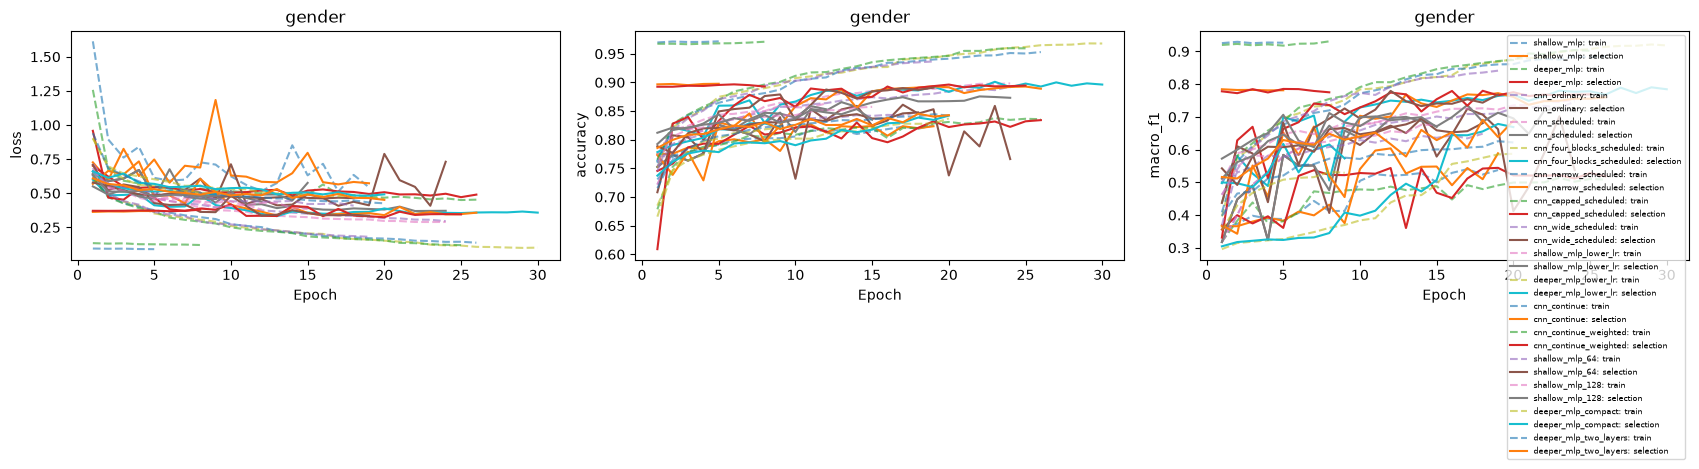

In [39]:
# Gender
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for method, history in histories['gender'].items():
    history = history.copy()
    history.insert(0, 'epoch', np.arange(1, len(history) + 1))
    history.to_csv(RESULTS / f"{stem_for('gender')}_{method}_history.csv", index=False)
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(history.epoch, history[metric], linestyle='--', alpha=0.6, label=f'{method}: train')
        ax.plot(history.epoch, history[f'val_{metric}'], label=f'{method}: selection')
        ax.set(xlabel='Epoch', ylabel=metric, title='gender')
axes[-1].legend(fontsize=6)
fig.tight_layout()


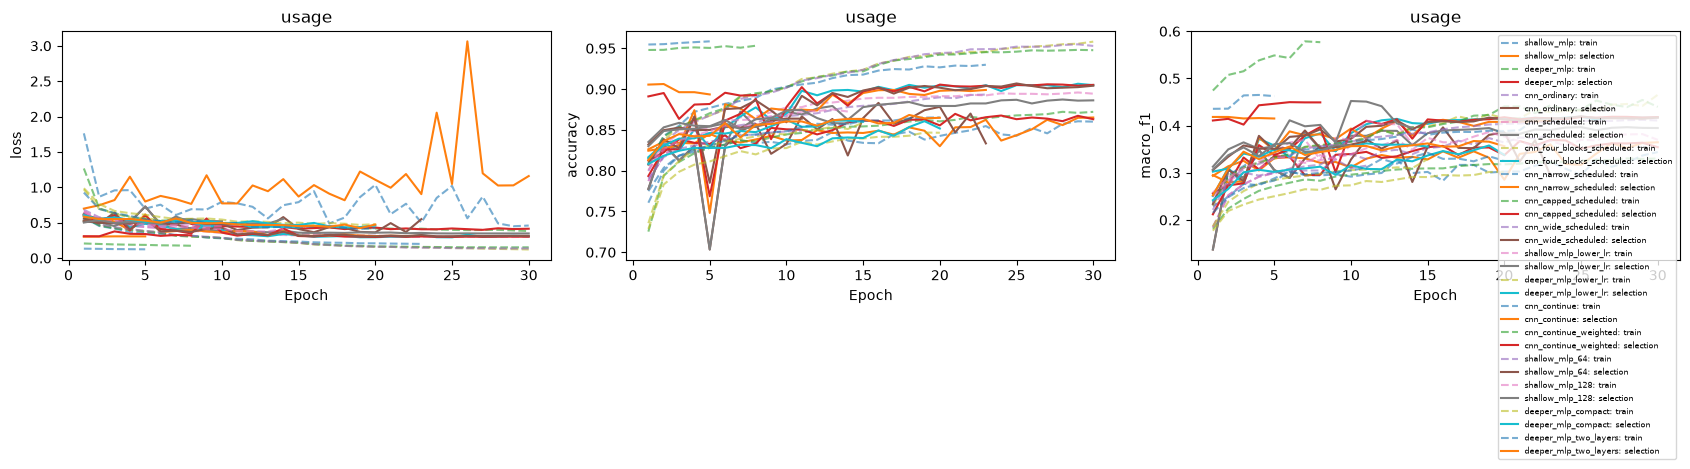

In [40]:
# Occasion (usage)
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for method, history in histories['usage'].items():
    history = history.copy()
    history.insert(0, 'epoch', np.arange(1, len(history) + 1))
    history.to_csv(RESULTS / f"{stem_for('usage')}_{method}_history.csv", index=False)
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(history.epoch, history[metric], linestyle='--', alpha=0.6, label=f'{method}: train')
        ax.plot(history.epoch, history[f'val_{metric}'], label=f'{method}: selection')
        ax.set(xlabel='Epoch', ylabel=metric, title='usage')
axes[-1].legend(fontsize=6)
fig.tight_layout()
plt.show()


### 5.6. Model Evaluation & Error Analysis

The following small inference helpers reproduce application preprocessing. Temperature scaling changes confidence, not the predicted class. Calibration is fitted on separate groups, then accepted only if policy-group NLL improves without worsening ECE.


#### 5.6.1. Prepare one inference image

Use the same RGB resizing and training-only normalization as the training batches.


In [41]:
def image_batch(image, image_size, mean, std):
    resized = image.convert("RGB").resize(tuple(image_size), Image.Resampling.BILINEAR)
    array = np.asarray(resized, dtype=np.float32) / 255.0
    array = (array - np.asarray(mean, dtype=np.float32)) / np.asarray(std, dtype=np.float32)
    return array[None, ...]


#### 5.6.2. Rescale confidence

Divide log probabilities by a positive temperature and renormalize.


In [42]:
def temperature_scale(probabilities, temperature=1.0):
    """Rescale confidence without changing the highest-probability class."""
    if not np.isfinite(temperature) or temperature <= 0:
        raise ValueError('Temperature must be finite and positive')
    values = np.asarray(probabilities, dtype=np.float64)
    if values.ndim < 1 or values.shape[-1] == 0 or not np.isfinite(values).all() or (values < 0).any():
        raise ValueError('Probabilities must be finite, nonnegative vectors')
    mass = values.sum(axis=-1, keepdims=True)
    if (mass <= 0).any():
        raise ValueError('Probability vectors must have positive mass')
    # Softmax is computed in float32; renormalize after conversion to float64.
    values = values / mass
    if temperature == 1.0:
        return values
    logits = np.log(np.clip(values, np.finfo(np.float64).tiny, 1.0)) / temperature
    logits -= logits.max(axis=-1, keepdims=True)
    scaled = np.exp(logits)
    return scaled / scaled.sum(axis=-1, keepdims=True)


#### 5.6.3. Notebook prediction interface

Use the same logits, labels and review-policy semantics as the web application. This class performs inference only.


In [43]:
class FashionClassifier:
    def __init__(self, checkpoint_path, device=None):
        checkpoint = checkpoint_path if isinstance(checkpoint_path, dict) else load_checkpoint(checkpoint_path)
        self.device = "/CPU:0" if device == "cpu" else (device if device and str(device).startswith("/") else None)
        self.target, self.labels = checkpoint["target"], list(checkpoint["labels"])
        self.temperature = float(checkpoint.get("temperature", 1.0))
        self.review_policy = checkpoint.get("review_policy")
        self.model_type = checkpoint["model_type"]
        self.model = checkpoint.get("model")
        self.members = None
        if self.model is not None:
            self.mean, self.std = checkpoint["mean"], checkpoint["std"]
            self.image_size = checkpoint["image_size"]
            self.estimator = self.feature_config = None
        else:
            raise ValueError("Classifier has no trained Keras model")

    def predict_batch(self, inputs):
        with tf.device(self.device):
            probabilities = tf.nn.softmax(self.model(inputs, training=False), axis=-1).numpy()
        return temperature_scale(probabilities, self.temperature)

    def predict_probabilities(self, image):
        inputs = image_batch(image, self.image_size, self.mean, self.std)
        return self.predict_batch(inputs)[0]

    def predict(self, image: Image.Image, top_k: int = 3) -> dict:
        if top_k < 1:
            raise ValueError("top_k must be positive")
        probabilities = self.predict_probabilities(image)
        count = min(top_k, len(self.labels))
        indices = np.argsort(probabilities)[::-1][:count]
        ranked = [
            {"label": self.labels[int(index)], "confidence": float(probabilities[index])}
            for index in indices
        ]
        result = {
            "target": self.target,
            "label": ranked[0]["label"],
            "confidence": ranked[0]["confidence"],
            "top_k": ranked,
        }
        if self.review_policy is not None:
            threshold = self.review_policy['threshold']
            result['needs_review'] = threshold is None or ranked[0]['confidence'] < threshold
            result['review_threshold'] = threshold
            result['confidence_calibrated'] = self.temperature != 1.0
            if self.review_policy.get('brightness_stability') and not result['needs_review']:
                stable_label = int(indices[0])
                unstable = any(
                    int(self.predict_probabilities(ImageEnhance.Brightness(image.convert('RGB')).enhance(factor)).argmax()) != stable_label
                    for factor in (0.8, 1.2)
                )
                if unstable:
                    result['needs_review'] = True
                    result['review_reason'] = 'Prediction changes with lighting'
        return result


#### 5.6.4. Evaluate a partition

Compute accuracy, supported-class macro-F1, ECE, NLL and Brier score. Record sampled batch/single-image differences as a diagnostic; large differences or changed predictions warn, while invalid probabilities raise an error.


In [44]:
def evaluate_saved_checkpoint(checkpoint_path, frame, device="cpu", batch_size=64):
    """Re-evaluate a frozen artifact with the application's exact preprocessing.

    This never fits a model or changes its checkpoint. Batching changes only
    execution and may slightly affect floating-point scores; label ordering
    and saved temperature match the web API.
    """
    from sklearn.metrics import log_loss

    if frame.empty:
        raise ValueError("Evaluation requires at least one image")
    predictor = FashionClassifier(checkpoint_path, device=device)
    labels = predictor.labels
    truth = np.asarray([labels.index(label) for label in frame[predictor.target]])
    batches = []
    for start in range(0, len(frame), batch_size):
        inputs = []
        for path in frame.image_path.iloc[start:start + batch_size]:
            with Image.open(path) as source:
                inputs.append(image_batch(source, predictor.image_size, predictor.mean, predictor.std))
        batches.append(predictor.predict_batch(np.concatenate(inputs)))
    probabilities = np.vstack(batches)
    if (probabilities.shape != (len(frame), len(labels))
            or not np.isfinite(probabilities).all()
            or (probabilities < 0).any()
            or not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5, rtol=1e-5)):
        raise ValueError("Batch inference returned invalid probabilities")
    predictions = probabilities.argmax(1)
    metrics = {
        "accuracy": float(accuracy_score(truth, predictions)),
        "macro_f1": supported_macro_f1(truth, predictions),
        "ece": expected_calibration_error(truth, probabilities),
        "nll": float(log_loss(truth, probabilities, labels=np.arange(len(labels)))),
        "brier": float(np.mean(np.sum((probabilities - np.eye(len(labels))[truth]) ** 2, axis=1))),
    }
    # Batch and single-image GPU kernels can produce slightly different scores.
    # Sample this difference as a diagnostic, not a requirement for calibration.
    # A 0.001 absolute difference means 0.1 percentage points of probability;
    # it is a warning threshold, not a guarantee of equivalent predictions.
    import warnings

    positions = sorted({0, len(frame) // 2, len(frame) - 1})
    max_absolute_difference = 0.0
    prediction_mismatches = []
    for position in positions:
        with Image.open(frame.image_path.iloc[position]) as source:
            single = np.asarray(predictor.predict_probabilities(source))
        if (single.shape != probabilities[position].shape
                or not np.isfinite(single).all()
                or (single < 0).any()
                or not np.isclose(single.sum(), 1.0, atol=1e-5, rtol=1e-5)):
            raise ValueError("Single-image inference returned invalid probabilities")
        difference = float(np.max(np.abs(probabilities[position] - single)))
        max_absolute_difference = max(max_absolute_difference, difference)
        if predictions[position] != single.argmax():
            prediction_mismatches.append(position)
    inference_consistency = {
        "sample_count": len(positions),
        "max_absolute_difference": max_absolute_difference,
        "prediction_mismatch_positions": prediction_mismatches,
    }
    if max_absolute_difference > 1e-3 or prediction_mismatches:
        warnings.warn(
            f"Batch/single-image inference diagnostic: {inference_consistency}. "
            "Evaluation and calibration use batched probabilities. Inspect these "
            "differences before interpreting single-image application results.",
            RuntimeWarning, stacklevel=2,
        )
    return {"labels": labels, "truth": truth, "predictions": predictions,
            "probabilities": probabilities, "metrics": metrics,
            "inference_consistency": inference_consistency}


#### 5.6.5. Fit temperature and the review threshold

Search temperature on calibration groups, then use policy groups to decide whether to keep it and when to request manual review.


In [45]:
def calibrate(checkpoint, calibration, policy, device):
    checkpoint = dict(checkpoint)
    cal = evaluate_saved_checkpoint(checkpoint, calibration, device=str(device))
    raw = evaluate_saved_checkpoint(checkpoint, policy, device=str(device))
    fit = minimize_scalar(lambda log_t: log_loss(
        cal['truth'], temperature_scale(cal['probabilities'], np.exp(log_t)),
        labels=np.arange(len(checkpoint['labels']))),
        bounds=(np.log(0.25), np.log(10)), method='bounded')
    temperature = float(np.exp(fit.x))
    scaled = temperature_scale(raw['probabilities'], temperature)
    if (log_loss(raw['truth'], scaled, labels=np.arange(len(checkpoint['labels']))) < raw['metrics']['nll']
            and expected_calibration_error(raw['truth'], scaled) <= raw['metrics']['ece']):
        checkpoint['temperature'] = temperature
    else:
        scaled = raw['probabilities']
    threshold = None
    for value in np.round(np.arange(0.50, 1.00, 0.01), 2):
        accepted = scaled.max(1) >= value
        if accepted.sum() >= 100 and np.mean(scaled.argmax(1)[accepted] == raw['truth'][accepted]) >= 0.90:
            threshold = float(value)
            break
    checkpoint['review_policy'] = {'threshold': threshold, 'target_accuracy': 0.90,
                                   'minimum_policy_samples': 100,
                                   'brightness_stability': checkpoint['target'] == 'articleType'}
    return checkpoint


In [46]:
method = winners['gender']
checkpoints['gender'] = dict(target='gender', labels=labels_by_target['gender'], model=models['gender'][method], model_type=method, temperature=1.0, mean=normalisation['mean'], std=normalisation['std'], image_size=list(IMAGE_SIZE), comparison_row=comparisons['gender'].loc[method].to_dict())
checkpoints['gender'] = calibrate(checkpoints['gender'], frames['gender']['calibration'], frames['gender']['policy'], DEVICE)
method = winners['usage']
checkpoints['usage'] = dict(target='usage', labels=labels_by_target['usage'], model=models['usage'][method], model_type=method, temperature=1.0, mean=normalisation['mean'], std=normalisation['std'], image_size=list(IMAGE_SIZE), comparison_row=comparisons['usage'].loc[method].to_dict())
checkpoints['usage'] = calibrate(checkpoints['usage'], frames['usage']['calibration'], frames['usage']['policy'], DEVICE)


#### 5.6.6. Evaluate the selected model on the internal test

Do not revise the architecture based on this table. Report prior development exposure and inspect per-class support before interpreting overall accuracy.


In [47]:
test_results = {}
result = evaluate_saved_checkpoint(checkpoints['gender'], metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('test')], device=DEVICE)
test_results['gender'] = result
checkpoints['gender']['test_metrics'] = result['metrics']
display(pd.Series(result['metrics'], name='gender'))
report = classification_report(result['truth'], result['predictions'], labels=np.arange(len(result['labels'])), target_names=result['labels'], output_dict=True, zero_division=0)
display(pd.DataFrame(report).T)
pd.DataFrame(report).T.to_csv(RESULTS / f"{stem_for('gender')}_test_per_class.csv")
pd.Series(result['metrics']).to_csv(RESULTS / f"{stem_for('gender')}_test_metrics.csv")
result = evaluate_saved_checkpoint(checkpoints['usage'], metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('test')], device=DEVICE)
test_results['usage'] = result
checkpoints['usage']['test_metrics'] = result['metrics']
display(pd.Series(result['metrics'], name='usage'))
report = classification_report(result['truth'], result['predictions'], labels=np.arange(len(result['labels'])), target_names=result['labels'], output_dict=True, zero_division=0)
display(pd.DataFrame(report).T)
pd.DataFrame(report).T.to_csv(RESULTS / f"{stem_for('usage')}_test_per_class.csv")
pd.Series(result['metrics']).to_csv(RESULTS / f"{stem_for('usage')}_test_metrics.csv")


accuracy    0.886149
macro_f1    0.739602
ece         0.011450
nll         0.301715
brier       0.161280
Name: gender, dtype: float64

,precision,recall,f1-score,support
Boys,0.692308,0.692308,0.692308,130.000000
Girls,0.717647,0.549550,0.622449,111.000000
Men,0.902134,0.941158,0.921233,3144.000000
Unisex,0.638298,0.505051,0.563910,297.000000
Women,0.908954,0.887525,0.898111,2036.000000
accuracy,0.886149,0.886149,0.886149,0.886149
macro avg,0.771868,0.715118,0.739602,5718.000000
weighted avg,0.882507,0.886149,0.883435,5718.000000


accuracy    0.856943
macro_f1    0.374519
ece         0.023051
nll         0.460779
brier       0.216802
Name: usage, dtype: float64

,precision,recall,f1-score,support
Casual,0.882842,0.937340,0.909275,4309.000000
Ethnic,0.850136,0.751807,0.797954,415.000000
Formal,0.726073,0.656716,0.689655,335.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,23.000000
Party,0.000000,0.000000,0.000000,2.000000
Smart Casual,0.000000,0.000000,0.000000,7.000000
Sports,0.695560,0.526400,0.599271,625.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.856943,0.856943,0.856943,0.856943


#### 5.6.7. Confidence bins

Compare average confidence with actual accuracy within each bin. Low-support bins are less reliable.


In [48]:
def calibration_table(truth: np.ndarray, probabilities: np.ndarray) -> pd.DataFrame:
    """Return a ten-bin reliability table for notebook evidence."""
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == np.asarray(truth)
    frame = pd.DataFrame({"confidence": confidence, "correct": correct})
    frame["bin"] = pd.cut(
        frame.confidence, bins=np.linspace(0, 1, 11), include_lowest=True
    )
    return frame.groupby("bin", observed=False).agg(
        mean_confidence=("confidence", "mean"),
        accuracy=("correct", "mean"),
        samples=("correct", "size"),
    )


In [49]:
result = test_results['gender']
display(calibration_table(result['truth'], result['probabilities']))
result = test_results['usage']
display(calibration_table(result['truth'], result['probabilities']))


,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",0.271770,0.800000,5
"(0.3, 0.4]",0.369158,0.378049,82
"(0.4, 0.5]",0.456710,0.388626,211
"(0.5, 0.6]",0.550079,0.601911,314
"(0.6, 0.7]",0.649391,0.676375,309
"(0.7, 0.8]",0.754619,0.743902,410
"(0.8, 0.9]",0.856417,0.870717,642


,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",NaN,NaN,0
"(0.3, 0.4]",0.368739,0.500000,6
"(0.4, 0.5]",0.475734,0.525253,99
"(0.5, 0.6]",0.548353,0.566116,484
"(0.6, 0.7]",0.649214,0.666667,453
"(0.7, 0.8]",0.753078,0.806122,588
"(0.8, 0.9]",0.856686,0.875764,982


#### 5.6.8. Confusion matrices

Rows are true labels and columns are predicted labels. The article-type plot groups uncommon predicted classes into an Other column for readability.


Text(0.5, 1.0, 'gender: selected checkpoint / internal test')

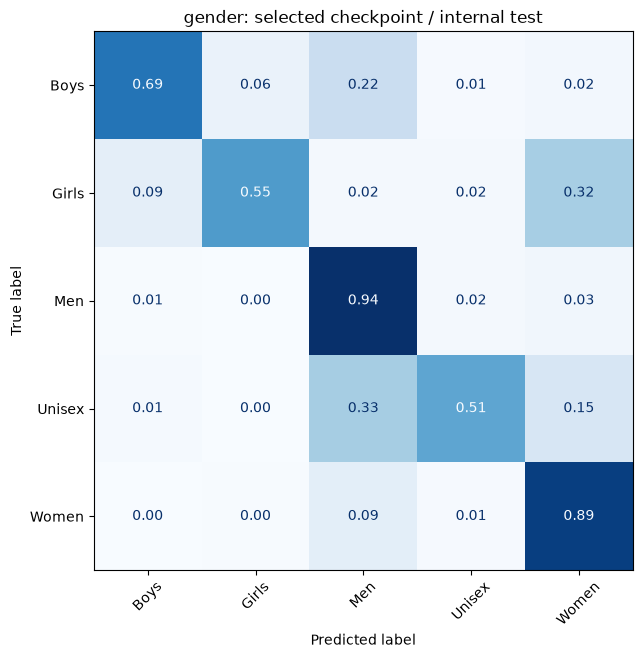

In [50]:
# Gender
from sklearn.metrics import confusion_matrix
import seaborn as sns
directory = RESULTS
stem = stem_for('gender')
result = test_results['gender']
labels = result['labels']
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(result['truth'], result['predictions'], labels=np.arange(len(labels)), display_labels=labels, normalize='true', values_format='.2f', xticks_rotation=45, ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"{'gender'}: selected checkpoint / internal test")


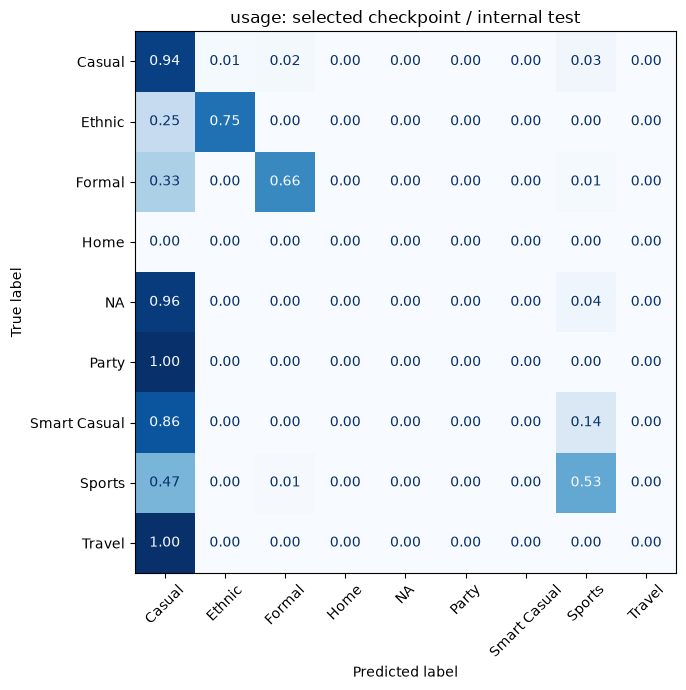

In [51]:
# Occasion (usage)
fig.tight_layout()
plt.show()
directory = RESULTS
stem = stem_for('usage')
result = test_results['usage']
labels = result['labels']
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(result['truth'], result['predictions'], labels=np.arange(len(labels)), display_labels=labels, normalize='true', values_format='.2f', xticks_rotation=45, ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"{'usage'}: selected checkpoint / internal test")
fig.tight_layout()
plt.show()


## 6. Ultimate Judgement

The executed comparison and decision tables identify the experimental winner using selection macro-F1, then accuracy, then parameter count. Internal-test results describe the selected model after that decision and must not determine the ranking. This experimental winner can differ from the final main-run winner.


In [52]:
winner = comparisons['gender'].loc[winners['gender']]
baseline = comparisons['gender'].loc[comparisons['gender']['family'].eq('shallow_mlp')].iloc[0]
display(pd.Series({'selected_method': winners['gender'], 'selection_macro_f1': winner.validation_macro_f1, 'selection_accuracy': winner.validation_accuracy, 'macro_f1_gain_over_baseline': winner.validation_macro_f1 - baseline.validation_macro_f1, 'internal_test_accuracy': test_results['gender']['metrics']['accuracy'], 'internal_test_macro_f1': test_results['gender']['metrics']['macro_f1']}, name='gender'))
winner = comparisons['usage'].loc[winners['usage']]
baseline = comparisons['usage'].loc[comparisons['usage']['family'].eq('shallow_mlp')].iloc[0]
display(pd.Series({'selected_method': winners['usage'], 'selection_macro_f1': winner.validation_macro_f1, 'selection_accuracy': winner.validation_accuracy, 'macro_f1_gain_over_baseline': winner.validation_macro_f1 - baseline.validation_macro_f1, 'internal_test_accuracy': test_results['usage']['metrics']['accuracy'], 'internal_test_macro_f1': test_results['usage']['metrics']['macro_f1']}, name='usage'))


selected_method                cnn_four_blocks_scheduled
selection_macro_f1                              0.790899
selection_accuracy                              0.898621
macro_f1_gain_over_baseline                     0.079147
internal_test_accuracy                          0.886149
internal_test_macro_f1                          0.739602
Name: gender, dtype: object

selected_method                shallow_mlp_lower_lr
selection_macro_f1                         0.452185
selection_accuracy                         0.873793
macro_f1_gain_over_baseline                     0.0
internal_test_accuracy                     0.856943
internal_test_macro_f1                     0.374519
Name: usage, dtype: object

### 6.1. Decision Analysis

The executed comparison and decision tables identify the experimental winner using selection macro-F1, then accuracy, then parameter count. Internal-test results describe the selected model after that decision and must not determine the ranking. This experimental winner can differ from the final main-run winner.


## 7. Final Prediction

Save the selected model, reload it, and predict a sample image. Exported metadata allows the standalone prediction scripts and web application to apply the same preprocessing and confidence policy.


In [53]:
def save_checkpoint(checkpoint, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path = path.with_suffix(".keras")
    model = checkpoint["model"]
    metadata = {key: value for key, value in checkpoint.items() if key != "model"}
    metadata = json.loads(json.dumps(metadata, default=lambda value: value.item()))
    model.get_layer("metadata").metadata = metadata
    # Export architecture, learned weights and metadata without optimizer slots.
    inference_model = type(model).from_config(model.get_config())
    inference_model.set_weights(model.get_weights())
    inference_model.save(path)
    return path


In [54]:
stem, method = (stem_for('gender'), winners['gender'])
path = save_checkpoint(checkpoints['gender'], OUTPUT / f'{stem}_model.keras')
histories['gender'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(target='gender', selected=method, cnn_selected=ranked(tuning['gender']).index[0], framework='tensorflow_keras', model_file=path.name, test_metrics=test_results['gender']['metrics'], split_sizes={name: len(frame) for name, frame in frames['gender'].items()}, test_scope='internal_test_with_prior_development_exposure')
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)
stem, method = (stem_for('usage'), winners['usage'])
path = save_checkpoint(checkpoints['usage'], OUTPUT / f'{stem}_model.keras')
histories['usage'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(target='usage', selected=method, cnn_selected=ranked(tuning['usage']).index[0], framework='tensorflow_keras', model_file=path.name, test_metrics=test_results['usage']['metrics'], split_sizes={name: len(frame) for name, frame in frames['usage'].items()}, test_scope='internal_test_with_prior_development_exposure')
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)


Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models-test/gender_model.keras


Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models-test/usage_model.keras


### 7.1. Load the Saved Model & Predict

A successful reload checks the saved architecture and metadata. This example is a functional check, not an independent quality estimate.


In [55]:
def resolve_classifier_path(path):
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(f"Missing trained classifier: {path}. Run the classification notebook first.")

def load_checkpoint(path):
    path = resolve_classifier_path(path)
    if path.suffix == ".keras":
        model = keras.models.load_model(path, compile=False)
        return {**dict(model.get_layer("metadata").metadata), "model": model}
    raise ValueError(f"Unsupported classifier format: {path.suffix}")


In [56]:
predictor = FashionClassifier(OUTPUT / f"{stem_for('gender')}_model.keras")
with Image.open(frames['gender']['selection'].image_path.iloc[0]) as image:
    print(predictor.predict(image))
predictor = FashionClassifier(OUTPUT / f"{stem_for('usage')}_model.keras")
with Image.open(frames['usage']['selection'].image_path.iloc[0]) as image:
    print(predictor.predict(image))


{'target': 'gender', 'label': 'Men', 'confidence': 0.7404636523919552, 'top_k': [{'label': 'Men', 'confidence': 0.7404636523919552}, {'label': 'Women', 'confidence': 0.2137302952025407}, {'label': 'Unisex', 'confidence': 0.03974882964627784}], 'needs_review': False, 'review_threshold': 0.5, 'confidence_calibrated': True}


{'target': 'usage', 'label': 'Sports', 'confidence': 0.9324994037681789, 'top_k': [{'label': 'Sports', 'confidence': 0.9324994037681789}, {'label': 'Casual', 'confidence': 0.06737449100602838}, {'label': 'Ethnic', 'confidence': 6.173456523976084e-05}], 'needs_review': False, 'review_threshold': 0.56, 'confidence_calibrated': False}


## 8. Conclusion

This notebook retains executed evidence for the architecture and optimization investigation, including selection comparisons, class-level errors and the experimental model export. Its outputs remain separate from production artifacts. Conclusions are limited by class imbalance, sparse minority support and prior internal-test exposure; use the main notebooks for the submitted final-model results.


## 9. Verify All Experimental Exports

Verify each candidate file, its architecture metadata and its output against its in-memory model. The manifest lists every candidate and selected export for later review.


In [57]:
export_manifest = []

for method, candidate in models['gender'].items():
    path = OUTPUT / f"{stem_for('gender')}_{method}.keras"
    restored = keras.models.load_model(path, compile=False)
    metadata = restored.get_layer('metadata').metadata
    assert metadata['target'] == 'gender' and metadata['model_type'] == method
    assert metadata['labels'] == labels_by_target['gender']
    probe = loaders['gender']['selection'][0][0][:1]
    np.testing.assert_allclose(candidate(probe, training=False).numpy(), restored(probe, training=False).numpy(), atol=1e-5, rtol=1e-4)
    export_manifest.append(dict(target='gender', method=method, file=path.name, selected=method == winners['gender'], bytes=path.stat().st_size, sha256=hashlib.sha256(path.read_bytes()).hexdigest()))
    del restored
assert (OUTPUT / f"{stem_for('gender')}_model.keras").is_file()

for method, candidate in models['usage'].items():
    path = OUTPUT / f"{stem_for('usage')}_{method}.keras"
    restored = keras.models.load_model(path, compile=False)
    metadata = restored.get_layer('metadata').metadata
    assert metadata['target'] == 'usage' and metadata['model_type'] == method
    assert metadata['labels'] == labels_by_target['usage']
    probe = loaders['usage']['selection'][0][0][:1]
    np.testing.assert_allclose(candidate(probe, training=False).numpy(), restored(probe, training=False).numpy(), atol=1e-5, rtol=1e-4)
    export_manifest.append(dict(target='usage', method=method, file=path.name, selected=method == winners['usage'], bytes=path.stat().st_size, sha256=hashlib.sha256(path.read_bytes()).hexdigest()))
    del restored
assert (OUTPUT / f"{stem_for('usage')}_model.keras").is_file()
pd.DataFrame(export_manifest).to_csv(RESULTS / 'task3_occasion_gender_classification_model_manifest.csv', index=False)
display(pd.DataFrame(export_manifest))


,target,method,file,selected,bytes,sha256
0,gender,shallow_mlp,gender_shallow_mlp.keras,False,113295255,e81abee9725387e0f70a7a155e8a74c47fed9071bf0b30...
1,gender,deeper_mlp,gender_deeper_mlp.keras,False,113791695,79df0ff8962837b2f5e1415cfce9e23f86533b016a801f...
2,gender,cnn_ordinary,gender_cnn_ordinary.keras,False,2000746,cfdcefd184567d3e3469478e713b30331b64f1ab37c716...
3,gender,cnn_scheduled,gender_cnn_scheduled.keras,False,2000759,a4e257e8d3e14fb53571b8ff72293d85f07678df15d905...
4,gender,cnn_four_blocks_scheduled,gender_cnn_four_blocks_scheduled.keras,True,7935966,2889bd08a3c46b90aeb5fc2ed3abb9b48bb3f5e6c760ae...
5,gender,cnn_narrow_scheduled,gender_cnn_narrow_scheduled.keras,False,2863713,db18117982a76a6a84c6a500e9fc23c8d6748fc807b117...
6,gender,cnn_capped_scheduled,gender_cnn_capped_scheduled.keras,False,4588004,2fb0c256b81efbc41c390868efa1e3277a9bfd508b93a1...
7,gender,cnn_wide_scheduled,gender_cnn_wide_scheduled.keras,False,11283937,0d1abde1971e952381aa0d4b72f80d97d51a57a90a5170...
8,gender,shallow_mlp_lower_lr,gender_shallow_mlp_lower_lr.keras,False,113295292,cdb0d1579a4aa977fda2e468160ae63fa8ac0e1d92894f...
9,gender,deeper_mlp_lower_lr,gender_deeper_mlp_lower_lr.keras,False,113791724,658a8212e8fae01785ed81773bddb6422123c7a5dba7e3...
